# Выпускной проект (Промышленность)

# Описание исследования:

Чтобы оптимизировать производственные расходы, металлургический комбинат «Стальная птица» решил уменьшить потребление электроэнергии на этапе обработки стали. Для этого комбинату нужно контролировать температуру сплава. Ваша задача — построить модель, которая будет её предсказывать. 

Заказчик хочет использовать разработанную модель для имитации технологического процесса. Ниже расскажем о деталях этого процесса.

**Описание этапа обработки**

Сталь обрабатывают в металлическом ковше вместимостью около 100 тонн. Чтобы ковш выдерживал высокие температуры, изнутри его облицовывают огнеупорным кирпичом. Расплавленную сталь заливают в ковш и подогревают до нужной температуры графитовыми электродами. Они установлены в крышке ковша. 
Из сплава выводится сера (этот процесс — десульфурация), добавлением примесей корректируется химический состав и отбираются пробы. Сталь легируют — изменяют её состав — подавая куски сплава из бункера для сыпучих материалов или проволоку через специальный трайб-аппарат (от англ. tribe — «масса»).
Перед тем как первый раз ввести легирующие добавки, измеряют температуру стали и производят её химический анализ. Потом температуру на несколько минут повышают, добавляют легирующие материалы и продувают сплав инертным газом. Затем его перемешивают и снова проводят измерения. Такой цикл повторяется до достижения целевого химического состава и оптимальной температуры плавки.
Тогда расплавленная сталь отправляется на доводку металла или поступает в машину непрерывной разливки. Оттуда готовый продукт выходит в виде заготовок-слябов (от англ. slab — «плита»).

# Цель исследования:

Построить модель, которая будет предсказывать температуру сплава.

# Задачи исследования:

1. Загрузить данные и выполнить их первичный осмотр
2. Провести исследовательский анализ и сделать предобработку данных при необходимости каждого датафрейма и сделать выводы 
3. Объединить выбранные признаки в один датафрейм, если это поможет в исследовании
4. Сделать предобработку данных объединённого датафрейма
5. Провести исследовательский анализ объединённого датафрейма и сделать выводы 
6. Подготовить данные для обучения модели
7. Обучить модели машинного обучения
8. Выбрать лучшую модель и проверить её качество
9. Сделать общий вывод об исследовании

# Исходные данные

Данные состоят из нескольких файлов, полученных из разных источников:
- `data_arc_new.csv` — данные об электродах;
- `data_bulk_new.csv` — данные о подаче сыпучих материалов (объём);
- `data_bulk_time_new.csv` — данные о подаче сыпучих материалов (время);
- `data_gas_new.csv` — данные о продувке сплава газом;
- `data_temp_new.csv` — результаты измерения температуры;
- `data_wire_new.csv` — данные о проволочных материалах (объём);
- `data_wire_time_new.csv` — данные о проволочных материалах (время).

Файл `data_arc_new.csv`

- `key` — номер партии;
- `Начало нагрева дугой` — время начала нагрева;
- `Конец нагрева дугой` — время окончания нагрева;
- `Активная мощность` — значение активной мощности;
- `Реактивная мощность` — значение реактивной мощности.

Файл `data_bulk_new.csv`

- `key` — номер партии;
- `Bulk 1 … Bulk 15` — объём подаваемого материала.

Файл `data_bulk_time_new.csv`

- `key` — номер партии;
- `Bulk 1 … Bulk 15` — время подачи материала.

Файл `data_gas_new.csv`

- `key` — номер партии;
- `Газ 1` — объём подаваемого газа.

Файл `data_temp_new.csv`

- `key` — номер партии;
- `Время замера` — время замера;
- `Температура` — значение температуры.

Файл `data_wire_new.csv`

- `key` — номер партии;
- `Wire 1 … Wire 9` — объём подаваемых проволочных материалов.

Файл `data_wire_time_new.csv`

- `key` — номер партии;
- `Wire 1 … Wire 9` — время подачи проволочных материалов.

**Прмечание:** Во всех файлах столбец  `key` содержит номер партии. В файлах может быть несколько строк с одинаковым значением `key`: они соответствуют разным итерациям обработки.

**Импортируем и установим все необходимые библиотеки для исследования:**

(некоторые библиотеки могут установиться не с первого раза)

**Примечание:** важно установить именно эти версии библиотек, так как при них корректно работает библиотека shap

In [3]:
!pip install numpy==1.26.4 

In [4]:
!pip install matplotlib==3.5.0

In [7]:
!pip install -q --upgrade scikit-learn

In [6]:
!pip install shap 

     |████████████████████████████████| 16.8 MB 1.3 MB/s eta 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.4
    Uninstalling numpy-1.24.4:
      Successfully uninstalled numpy-1.24.4


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import datetime
import sklearn
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from catboost import CatBoostRegressor
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import make_scorer
import shap

RANDOM_STATE = 220425
TEST_SIZE = 0.25

## Загрузка данных

**Загрузим данные**

Считаем CSV-файлы с данными с помощью библиотеки `pandas` и сохраним их в датафреймы.

In [2]:
data_arc_new = pd.read_csv('/datasets/data_arc_new.csv')
data_bulk_new = pd.read_csv('/datasets/data_bulk_new.csv')
data_bulk_time_new = pd.read_csv('/datasets/data_bulk_time_new.csv')
data_gas_new = pd.read_csv('/datasets/data_gas_new.csv')
data_temp_new = pd.read_csv('/datasets/data_temp_new.csv')
data_wire_new = pd.read_csv('/datasets/data_wire_new.csv')
data_wire_time_new = pd.read_csv('/datasets/data_wire_time_new.csv')

Создадим список с загруженными датафреймами и их именами:

In [3]:
dataframe_list = [data_arc_new, data_bulk_new, data_bulk_time_new, data_gas_new, data_temp_new, 
                  data_wire_new, data_wire_time_new]
dataframe_list_name = ['data_arc_new', 'data_bulk_new', 'data_bulk_time_new', 'data_gas_new', 'data_temp_new', 
                       'data_wire_new', 'data_wire_time_new']

Выведем первые строки всех датафреймов, изучим их и сделаем выводы: 

In [4]:
for df, df_name in zip(dataframe_list, dataframe_list_name):
    display('Название датафрейма: ' + df_name)
    display(df.head())
    print(' ')

'Название датафрейма: data_arc_new'

,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691


'Название датафрейма: data_bulk_new'

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaN,NaN,NaN,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,150.0,154.0
1,2,NaN,NaN,NaN,73.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,149.0,154.0
2,3,NaN,NaN,NaN,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205.0,NaN,152.0,153.0
3,4,NaN,NaN,NaN,81.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,207.0,NaN,153.0,154.0
4,5,NaN,NaN,NaN,78.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,203.0,NaN,151.0,152.0


'Название датафрейма: data_bulk_time_new'

...

,key,Время замера,Температура
0,1,2019-05-03 11:02:04,1571.0
1,1,2019-05-03 11:07:18,1604.0
2,1,2019-05-03 11:11:34,1618.0
3,1,2019-05-03 11:18:04,1601.0
4,1,2019-05-03 11:25:59,1606.0


'Название датафрейма: data_wire_new'

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,60.059998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,96.052315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,91.160157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,89.063515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,89.238236,9.11456,NaN,NaN,NaN,NaN,NaN,NaN,NaN


'Название датафрейма: data_wire_time_new'

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,2019-05-03 11:06:19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2019-05-03 11:36:50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2019-05-03 12:11:46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2019-05-03 12:43:22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2019-05-03 13:20:44,2019-05-03 13:15:34,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Можно говорить о том, что CSV-файлы считались правильно, и с такими датафреймами уже можно работать.

**Промежуточный вывод:**
- загруженные CSV-файлы считались верно
- по результатам просмотра содержимого датафреймов необходимо:
    - привести названия столбцов к "должному" виду (латиница, строчные буквы, змеевидная запись(через нижнее подчеркивание))
    - изучить данные на пропуски и принять решение удалить или оставить
    - проверить данные на наличие дубликатов
    - проверить типы данных

Проделаем выделенные шаги в следующем пункте.

## Исследовательский анализ

Изучим данные и сделаем выводы.

### Изучим общую информацию о датафреймах

Теперь для лучшего понимания данных, хранящихся в датафреймах, выведем информацию о них методом `.info()`. Для оптимизации процесса напишем функцию `dataframe_info()`, которая удет это делать:

In [5]:
def dataframe_info(dataframe_list, dataframe_list_name):
    for df, df_name in zip(dataframe_list, dataframe_list_name):
        display('Название датафрейма: ' + df_name)
        display('Размеры датафрейма: ', df.shape)    
        display(df.info())
        print(' ')

Вызовем её и посмотрим на результаты вывода:

In [6]:
dataframe_info(dataframe_list, dataframe_list_name)

'Название датафрейма: data_arc_new'

'Размеры датафрейма: '

(14876, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   key                   14876 non-null  int64  
 1   Начало нагрева дугой  14876 non-null  object 
 2   Конец нагрева дугой   14876 non-null  object 
 3   Активная мощность     14876 non-null  float64
 4   Реактивная мощность   14876 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 581.2+ KB


None

...

'Название датафрейма: data_wire_time_new'

'Размеры датафрейма: '

(3081, 10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   key     3081 non-null   int64 
 1   Wire 1  3055 non-null   object
 2   Wire 2  1079 non-null   object
 3   Wire 3  63 non-null     object
 4   Wire 4  14 non-null     object
 5   Wire 5  1 non-null      object
 6   Wire 6  73 non-null     object
 7   Wire 7  11 non-null     object
 8   Wire 8  19 non-null     object
 9   Wire 9  29 non-null     object
dtypes: int64(1), object(9)
memory usage: 240.8+ KB


None

Из вывода общей информации по датафреймам можно говорить следующее:
1. Названия столбцов не соотвествуют "правильной" записи
2. Размеры датафреймов разные как по строкам, так и по столбцам
3. Явное присутствие пропусков в данных
4. Некоторые типы данных не соответствуют действительности 

Проверим и при необходимости изменим данные датафреймов.

### Приведем названия столбцов к правильной записи

Из полученной ранее информации видно, что необходимо привести названия столбцов датафрейма к общепринятому виду - прописные строчные буквы, "змеевидная" запись(через нижнее подчеркивание), латинский алфавит.

Для оптимизации процесса напишем функцию `col_rename_dataframe()`, которая проведет необходимые операции:

In [7]:
def col_rename_dataframe(dataframe_list, dataframe_list_name):
    for df, df_name in zip(dataframe_list, dataframe_list_name):
        df.columns = df.columns.str.replace(r'\s+', '', regex=True).str.replace(r'(\d+)', r'_\1', regex=True).str.lower()

Теперь применим функцию `col_rename_dataframe()`:

In [8]:
col_rename_dataframe(dataframe_list, dataframe_list_name)

Посмотрим на изменения, вызвав `dataframe_info()`:

In [9]:
dataframe_info(dataframe_list, dataframe_list_name)

'Название датафрейма: data_arc_new'

'Размеры датафрейма: '

(14876, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   key                 14876 non-null  int64  
 1   началонагревадугой  14876 non-null  object 
 2   конецнагревадугой   14876 non-null  object 
 3   активнаямощность    14876 non-null  float64
 4   реактивнаямощность  14876 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 581.2+ KB


None

...

'Название датафрейма: data_wire_time_new'

'Размеры датафрейма: '

(3081, 10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   key     3081 non-null   int64 
 1   wire_1  3055 non-null   object
 2   wire_2  1079 non-null   object
 3   wire_3  63 non-null     object
 4   wire_4  14 non-null     object
 5   wire_5  1 non-null      object
 6   wire_6  73 non-null     object
 7   wire_7  11 non-null     object
 8   wire_8  19 non-null     object
 9   wire_9  29 non-null     object
dtypes: int64(1), object(9)
memory usage: 240.8+ KB


None

Видно, что изменния произошли, однако из-за наличия кириллицы не везде. Применим ручное изменение названий столбцов на кириллице к латинице:

In [10]:
data_arc_new = data_arc_new.rename(columns={    'началонагревадугой':'beginning_of_arc_heating', 
                                                'конецнагревадугой':'end_of_arc_heating', 
                                                'активнаямощность':'active_power', 
                                                'реактивнаямощность':'reactive_power'})
data_gas_new = data_gas_new.rename(columns={    'газ_1':'gas_1'})
data_temp_new = data_temp_new.rename(columns={  'времязамера':'measurement_time', 
                                                'температура':'temperature'})

Обновим список датафреймов и снова посмотри общую информацию о них:

In [11]:
dataframe_list = [data_arc_new, data_bulk_new, data_bulk_time_new, data_gas_new, data_temp_new, 
                  data_wire_new, data_wire_time_new]

In [12]:
dataframe_info(dataframe_list, dataframe_list_name)

'Название датафрейма: data_arc_new'

'Размеры датафрейма: '

(14876, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   key                       14876 non-null  int64  
 1   beginning_of_arc_heating  14876 non-null  object 
 2   end_of_arc_heating        14876 non-null  object 
 3   active_power              14876 non-null  float64
 4   reactive_power            14876 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 581.2+ KB


None

...

'Название датафрейма: data_wire_time_new'

'Размеры датафрейма: '

(3081, 10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   key     3081 non-null   int64 
 1   wire_1  3055 non-null   object
 2   wire_2  1079 non-null   object
 3   wire_3  63 non-null     object
 4   wire_4  14 non-null     object
 5   wire_5  1 non-null      object
 6   wire_6  73 non-null     object
 7   wire_7  11 non-null     object
 8   wire_8  19 non-null     object
 9   wire_9  29 non-null     object
dtypes: int64(1), object(9)
memory usage: 240.8+ KB


None

In [13]:
for df, df_name in zip(dataframe_list, dataframe_list_name):
    display('Название датафрейма: ' + df_name)
    display(df.head())
    print(' ')

'Название датафрейма: data_arc_new'

,key,beginning_of_arc_heating,end_of_arc_heating,active_power,reactive_power
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691


'Название датафрейма: data_bulk_new'

,key,bulk_1,bulk_2,bulk_3,bulk_4,bulk_5,bulk_6,bulk_7,bulk_8,bulk_9,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15
0,1,NaN,NaN,NaN,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,150.0,154.0
1,2,NaN,NaN,NaN,73.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,149.0,154.0
2,3,NaN,NaN,NaN,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205.0,NaN,152.0,153.0
3,4,NaN,NaN,NaN,81.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,207.0,NaN,153.0,154.0
4,5,NaN,NaN,NaN,78.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,203.0,NaN,151.0,152.0


'Название датафрейма: data_bulk_time_new'

...

,key,measurement_time,temperature
0,1,2019-05-03 11:02:04,1571.0
1,1,2019-05-03 11:07:18,1604.0
2,1,2019-05-03 11:11:34,1618.0
3,1,2019-05-03 11:18:04,1601.0
4,1,2019-05-03 11:25:59,1606.0


'Название датафрейма: data_wire_new'

,key,wire_1,wire_2,wire_3,wire_4,wire_5,wire_6,wire_7,wire_8,wire_9
0,1,60.059998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,96.052315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,91.160157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,89.063515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,89.238236,9.11456,NaN,NaN,NaN,NaN,NaN,NaN,NaN


'Название датафрейма: data_wire_time_new'

,key,wire_1,wire_2,wire_3,wire_4,wire_5,wire_6,wire_7,wire_8,wire_9
0,1,2019-05-03 11:06:19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2019-05-03 11:36:50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2019-05-03 12:11:46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2019-05-03 12:43:22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2019-05-03 13:20:44,2019-05-03 13:15:34,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Видно, что все данные были приведены к "правильному" виду и с ними можно продолжать работать.

В дальнейшем будем рассматривать **каждый** датафрейм **по отдельности**, а не все вместе, так как для каждого из них могут потребоваться свои уникальные преобразования.

### Преобразование типа данных

Из предыдущего пункта можно выделить следующие датафрейемы, в которых тип дпнных не совпадает со своими "реальными" данными:
1. `data_arc_new`:
    - столбцы `beginning_of_arc_heating` и `end_of_arc_heating` имеют тип `object`, хотя содержат в себе данные типа `datatime`
2. `data_bulk_time_new`:
    - столбцы `bulk_1,...,bulk_15` также имеют тип `object`, хотя содержат - `datatime`
3. `data_temp_new`:
    - столбец `measurement_time` имеет тип `object`, но содержит - `datatime`
4. data_wire_time_new:
    - столбцы `wire_1,...,wire_15` также имеют тип `object`, хотя содержат - `datatime`

В определенных датасетах изменим типы данных:

In [14]:
bulk_list = data_bulk_time_new.drop(columns='key').columns
wire_list = data_wire_time_new.drop(columns='key').columns

In [15]:
data_arc_new['beginning_of_arc_heating'] = data_arc_new['beginning_of_arc_heating'].astype('datetime64')
data_arc_new['end_of_arc_heating'] = data_arc_new['end_of_arc_heating'].astype('datetime64')
data_temp_new['measurement_time'] = data_temp_new['measurement_time'].astype('datetime64')
data_bulk_time_new[bulk_list] = data_bulk_time_new[bulk_list].astype('datetime64')
data_wire_time_new[wire_list] = data_wire_time_new[wire_list].astype('datetime64')

Проверим изменения в датафреймах, вызвав функцию `dataframe_info`:

In [16]:
dataframe_info(dataframe_list, dataframe_list_name)

'Название датафрейма: data_arc_new'

'Размеры датафрейма: '

(14876, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   key                       14876 non-null  int64         
 1   beginning_of_arc_heating  14876 non-null  datetime64[ns]
 2   end_of_arc_heating        14876 non-null  datetime64[ns]
 3   active_power              14876 non-null  float64       
 4   reactive_power            14876 non-null  float64       
dtypes: datetime64[ns](2), float64(2), int64(1)
memory usage: 581.2 KB


None

...

'Название датафрейма: data_wire_time_new'

'Размеры датафрейма: '

(3081, 10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   key     3081 non-null   int64         
 1   wire_1  3055 non-null   datetime64[ns]
 2   wire_2  1079 non-null   datetime64[ns]
 3   wire_3  63 non-null     datetime64[ns]
 4   wire_4  14 non-null     datetime64[ns]
 5   wire_5  1 non-null      datetime64[ns]
 6   wire_6  73 non-null     datetime64[ns]
 7   wire_7  11 non-null     datetime64[ns]
 8   wire_8  19 non-null     datetime64[ns]
 9   wire_9  29 non-null     datetime64[ns]
dtypes: datetime64[ns](9), int64(1)
memory usage: 240.8 KB


None

Из повторной проверки видно, что тип данных изменился - теперь он соответствует действительности. Продолжим исследование.

### Проверим наличие пропусков в данных

Воспользуемся методом `.isna()` для поиска пропусков во всех датафреймах и просуммируем их методом `.sum()`. Напишем функцию `dataframe_skip()`, для оптимизации процесса:

In [17]:
def dataframe_skip(dataframe, dataframe_name):
    display('Название датафрейма: '+ dataframe_name)
    display('Размеры датафрейма: ', dataframe.shape)
    display(dataframe.isna().sum())            
    print('Процентное соотношение количества пропусков к общему числу данных:\n', round((dataframe.isna().sum() * 100) / len(dataframe),3))
    print(' ')

Рассмотрим каждый датафреймы, используя функцию `dataframe_skip()`:

**Данные об электродах**

In [18]:
dataframe_skip(data_arc_new, 'data_arc_new')

'Название датафрейма: data_arc_new'

'Размеры датафрейма: '

(14876, 5)

key                         0
beginning_of_arc_heating    0
end_of_arc_heating          0
active_power                0
reactive_power              0
dtype: int64

Процентное соотношение количества пропусков к общему числу данных:
 key                         0.0
beginning_of_arc_heating    0.0
end_of_arc_heating          0.0
active_power                0.0
reactive_power              0.0
dtype: float64
 


Из выводимой информации видим, что пропусков *нет*, что является **хорошим** показателем переданных нам данных.

**Данные о подаче сыпучих материалов (объём)**

In [19]:
dataframe_skip(data_bulk_new, 'data_bulk_new')

'Название датафрейма: data_bulk_new'

'Размеры датафрейма: '

(3129, 16)

key           0
bulk_1     2877
bulk_2     3107
bulk_3     1831
bulk_4     2115
bulk_5     3052
bulk_6     2553
bulk_7     3104
bulk_8     3128
bulk_9     3110
bulk_10    2953
bulk_11    2952
bulk_12     679
bulk_13    3111
bulk_14     323
bulk_15     881
dtype: int64

Процентное соотношение количества пропусков к общему числу данных:
 key         0.000
bulk_1     91.946
bulk_2     99.297
bulk_3     58.517
bulk_4     67.593
bulk_5     97.539
bulk_6     81.592
bulk_7     99.201
bulk_8     99.968
bulk_9     99.393
bulk_10    94.375
bulk_11    94.343
bulk_12    21.700
bulk_13    99.425
bulk_14    10.323
bulk_15    28.156
dtype: float64
 


**Данные о подаче сыпучих материалов (время)**

In [20]:
dataframe_skip(data_bulk_time_new, 'data_bulk_time_new')

'Название датафрейма: data_bulk_time_new'

'Размеры датафрейма: '

(3129, 16)

key           0
bulk_1     2877
bulk_2     3107
bulk_3     1831
bulk_4     2115
bulk_5     3052
bulk_6     2553
bulk_7     3104
bulk_8     3128
bulk_9     3110
bulk_10    2953
bulk_11    2952
bulk_12     679
bulk_13    3111
bulk_14     323
bulk_15     881
dtype: int64

Процентное соотношение количества пропусков к общему числу данных:
 key         0.000
bulk_1     91.946
bulk_2     99.297
bulk_3     58.517
bulk_4     67.593
bulk_5     97.539
bulk_6     81.592
bulk_7     99.201
bulk_8     99.968
bulk_9     99.393
bulk_10    94.375
bulk_11    94.343
bulk_12    21.700
bulk_13    99.425
bulk_14    10.323
bulk_15    28.156
dtype: float64
 


Из представленных данных видно, что структура датафреймов похожа, а также и количество пропусков в них и их процентное соотношение соответственно. Учитывая огромное количество пропусков у многих материалов, это можно связать с тем, какой материал используется или не используетс для производства.

В связи с этим мы **не будем** удалять пропуски (практически весь датасет) или заполнять их каким-либо значением (медиана, мода и т.п.), так как это может привести к критическому искажению данных, а следовательно и результатам исследования.

**Данные о продувке сплава газом**

In [21]:
dataframe_skip(data_gas_new, 'data_gas_new')

'Название датафрейма: data_gas_new'

'Размеры датафрейма: '

(3239, 2)

key      0
gas_1    0
dtype: int64

Процентное соотношение количества пропусков к общему числу данных:
 key      0.0
gas_1    0.0
dtype: float64
 


Из представленной информации видим, что пропусков *нет*, что является **хорошим** показателем переданных нам данных.

**Данные о проволочных материалах (объём)**

In [22]:
dataframe_skip(data_wire_new, 'data_wire_new')

'Название датафрейма: data_wire_new'

'Размеры датафрейма: '

(3081, 10)

key          0
wire_1      26
wire_2    2002
wire_3    3018
wire_4    3067
wire_5    3080
wire_6    3008
wire_7    3070
wire_8    3062
wire_9    3052
dtype: int64

Процентное соотношение количества пропусков к общему числу данных:
 key        0.000
wire_1     0.844
wire_2    64.979
wire_3    97.955
wire_4    99.546
wire_5    99.968
wire_6    97.631
wire_7    99.643
wire_8    99.383
wire_9    99.059
dtype: float64
 


**Данные о проволочных материалах (время)**

In [23]:
dataframe_skip(data_wire_time_new, 'data_wire_time_new')

'Название датафрейма: data_wire_time_new'

'Размеры датафрейма: '

(3081, 10)

key          0
wire_1      26
wire_2    2002
wire_3    3018
wire_4    3067
wire_5    3080
wire_6    3008
wire_7    3070
wire_8    3062
wire_9    3052
dtype: int64

Процентное соотношение количества пропусков к общему числу данных:
 key        0.000
wire_1     0.844
wire_2    64.979
wire_3    97.955
wire_4    99.546
wire_5    99.968
wire_6    97.631
wire_7    99.643
wire_8    99.383
wire_9    99.059
dtype: float64
 


Из представленных данных видно, что структура датафреймов проволочных материалов похожа, как и в случае с сыпучими материалами; также и количество пропусков в них и их процентное соотношение соответственно. Учитывая огромное количество пропусков у многих материалов, это можно связать с тем, какой материал используется или не используетс для производства.

В связи с этим мы **не будем** удалять пропуски (практически весь датасет) или заполнять их каким-либо значением (медиана, мода и т.п.), так как это может привести к критическому искажению данных, а следовательно и результатам исследования.

**Результаты измерения температуры**

In [24]:
dataframe_skip(data_temp_new, 'data_temp_new')

'Название датафрейма: data_temp_new'

'Размеры датафрейма: '

(18092, 3)

key                    0
measurement_time       0
temperature         3427
dtype: int64

Процентное соотношение количества пропусков к общему числу данных:
 key                  0.000
measurement_time     0.000
temperature         18.942
dtype: float64
 


Как видим пропуски присутствуют, причем процент достаточно большой - около 19%. Сейчас принимать решение об удалении такого числа данных рискованно, учитывая еще и тот факт, что это **целевой признак**.

В связи с этим на данном этапе исследования **оставим** данные и не будем проводить удаление пропусков, однако учтём их наличие при дальнейшем анализе данного датафрейма.

### Проверим данные на наличие дубликатов

Учитывая особенности наших данных, то будем проводить поиск только *явных* дубликатов, так как все данные численные.

Воспользуемся методом `.duplicated()`, чтобы найти *явные* дубликаты в датафрейме и после методом `.sum()` выведем их количество. Для оптимизации напишем функцию `dataframe_dupl()`:

In [25]:
def dataframe_dupl(dataframe_list, dataframe_list_name):
    for df, df_name in zip(dataframe_list, dataframe_list_name):
        display('Название датафрейма: ' + df_name)
        display('Размеры датафрейма: ', df.shape)    
        display(df.duplicated().sum())
        print(' ')

In [26]:
dataframe_dupl(dataframe_list, dataframe_list_name)

'Название датафрейма: data_arc_new'

'Размеры датафрейма: '

(14876, 5)

0

'Название датафрейма: data_bulk_new'

...

0

'Название датафрейма: data_wire_time_new'

'Размеры датафрейма: '

(3081, 10)

0

В результате наблюдаем, что *явных* дубликатов во всех датафреймах нет, что является весьма хорошим показателем.

### Углубленное исследование количественных переменных данных

Так как в переданных нам данных присутствуют только количественные величины, то рассмотрим для этого соответствующие действия.

Будем рассматривать каждый датафрейм **по отдельности**.

Напишем функцию, которая будет проводить подобный анализ для оптимизированного подхода к решению проблемы:

Воспользуемся методом `.describe()` для того, что вывести все признаки количественных переменных в датафреймах. Также выведем гистограмму для рассматриваемых признаков и диаграмму размаха. При анализе уберем столбец `'key'` у датафреймов, так как он показывает лишь номер партии, что является уникальным значение.

In [27]:
def dataframe_count_analyse(dataframe, dataframe_name, measure_x):
    display('Название датафрейма: '+ dataframe_name)
    display('Общая информация и размеры датафрейма: ', dataframe.shape)
    display(dataframe.info())
    display('Первые строки: ', dataframe.head(3))
    display('Описательные характеристики датафрейма: ')            
    display(dataframe.describe())            
    print(' ')
    print('Графическое представление признаков:')
    for i,j in zip(dataframe.describe().drop(columns='key').columns, measure_x):
        plt.figure(figsize=(20, 15))
        # Вывод графиков
        plt.subplot(2, 2, 1)
        # Шаблон для построения гистограммы
        dataframe[i].plot(kind='hist', bins=275, grid=True)
        plt.xlabel(j)
        plt.ylabel('Количество')
        plt.title('Признак ' + i)
        plt.subplot(2, 2, 2)
        # Шаблон для построения "ящика с усами"
        dataframe.boxplot(column=[i])
        plt.xticks([])
        plt.ylabel(j)

В дальнейшем для анализа датафреймов будем её использовать.

**Данные об электродах**

Изучим датафрейм:

'Название датафрейма: data_arc_new'

'Общая информация и размеры датафрейма: '

(14876, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   key                       14876 non-null  int64         
 1   beginning_of_arc_heating  14876 non-null  datetime64[ns]
 2   end_of_arc_heating        14876 non-null  datetime64[ns]
 3   active_power              14876 non-null  float64       
 4   reactive_power            14876 non-null  float64       
dtypes: datetime64[ns](2), float64(2), int64(1)
memory usage: 581.2 KB


None

'Первые строки: '

,key,beginning_of_arc_heating,end_of_arc_heating,active_power,reactive_power
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460


'Описательные характеристики датафрейма: '

,key,active_power,reactive_power
count,14876.000000,14876.000000,14876.000000
mean,1615.220422,0.662752,0.438986
std,934.571502,0.258885,5.873485
min,1.000000,0.223120,-715.479924
25%,806.000000,0.467115,0.337175
50%,1617.000000,0.599587,0.441639
75%,2429.000000,0.830070,0.608201
max,3241.000000,1.463773,1.270284


 
Графическое представление признаков:


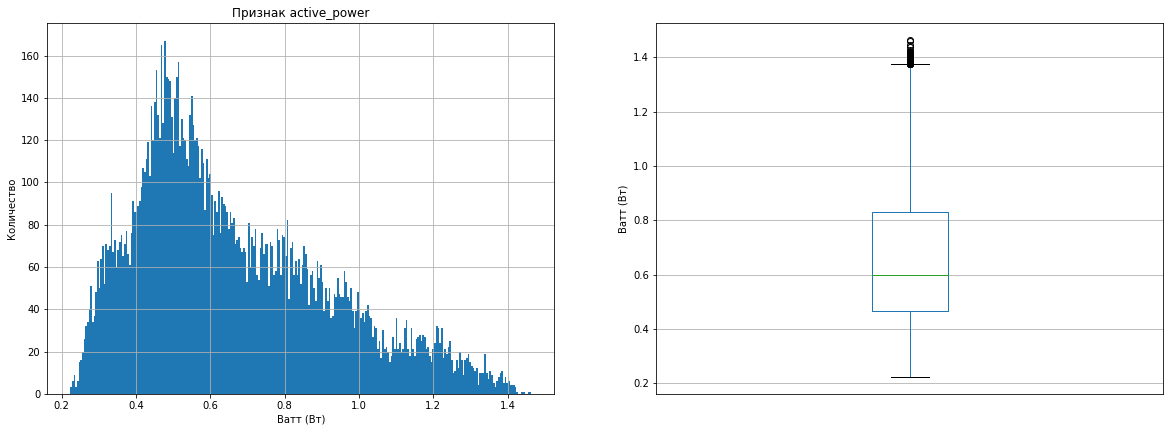

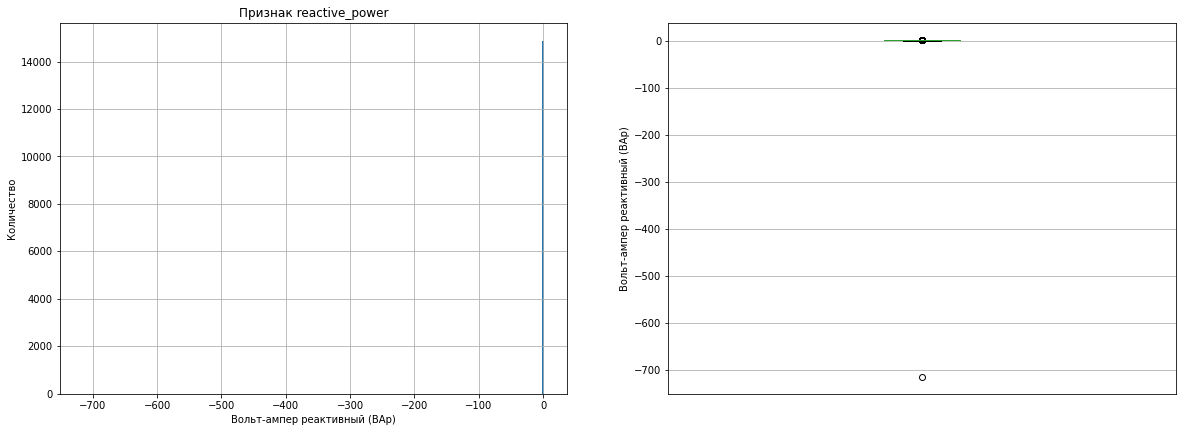

In [28]:
measure_x = ['Ватт (Вт)', 'Вольт-ампер реактивный (ВАр)']
dataframe_count_analyse(data_arc_new, 'data_arc_new', measure_x)

В результате изучения конкретно виден выброс в признаке `reactive_power` - значение `-715` не физично, так как реактивная мощность не может быть **отрицательной**, поэтому сделаем срез данных, чтобы убрать подобные значения:

In [29]:
data_arc_new = data_arc_new.query('reactive_power >= 0')

Повторно выведем графики для просмотра значений и анализа:

'Название датафрейма: data_arc_new'

'Общая информация и размеры датафрейма: '

(14875, 5)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 14875 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   key                       14875 non-null  int64         
 1   beginning_of_arc_heating  14875 non-null  datetime64[ns]
 2   end_of_arc_heating        14875 non-null  datetime64[ns]
 3   active_power              14875 non-null  float64       
 4   reactive_power            14875 non-null  float64       
dtypes: datetime64[ns](2), float64(2), int64(1)
memory usage: 697.3 KB


None

'Первые строки: '

,key,beginning_of_arc_heating,end_of_arc_heating,active_power,reactive_power
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460


'Описательные характеристики датафрейма: '

,key,active_power,reactive_power
count,14875.000000,14875.000000,14875.000000
mean,1615.186756,0.662749,0.487115
std,934.593897,0.258894,0.197612
min,1.000000,0.223120,0.153777
25%,806.000000,0.467115,0.337190
50%,1617.000000,0.599578,0.441665
75%,2429.000000,0.830135,0.608223
max,3241.000000,1.463773,1.270284


 
Графическое представление признаков:


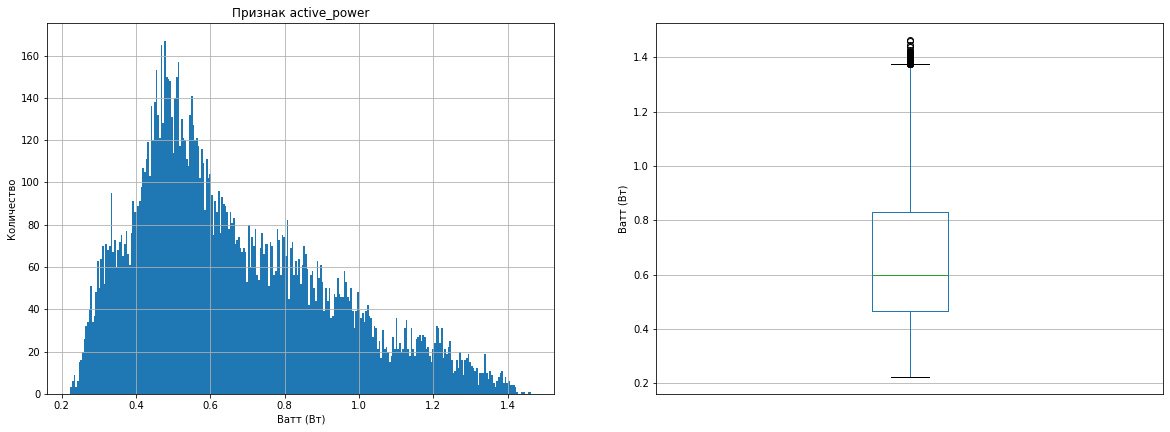

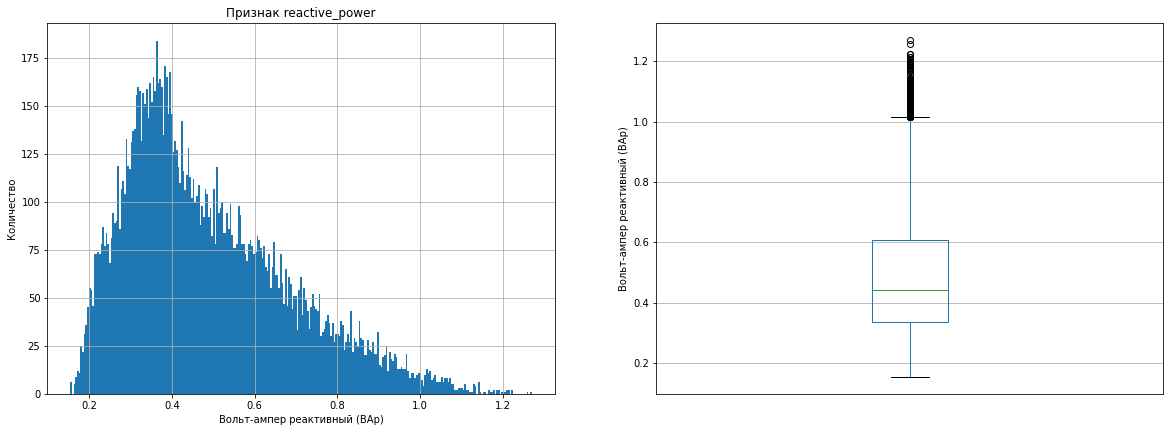

In [30]:
measure_x = ['Ватт (Вт)', 'Вольт-ампер реактивный (ВАр)']
dataframe_count_analyse(data_arc_new, 'data_arc_new', measure_x)

Как видно гистограммы имеют волнообразный вид, но точный закон их распределения назвать нельзя. Также из "ящика с усами" мы видим большое число выбросов в данных; определи процент выбросов в данных для каждого признака датафрейма:

In [31]:
display('Процентное соотношение выбросов значений активной мощности по отношению ко всему датафрейму:', \
        (round(((data_arc_new.query('active_power > 1.37')['active_power'].count()/len(data_arc_new))*100),5)))

'Процентное соотношение выбросов значений активной мощности по отношению ко всему датафрейму:'

0.5042

In [32]:
display('Процентное соотношение выбросов значений реактивной мощности по отношению ко всему датафрейму:', \
        (round(((data_arc_new.query('reactive_power > 1.05')['reactive_power'].count()/len(data_arc_new))*100),5)))

'Процентное соотношение выбросов значений реактивной мощности по отношению ко всему датафрейму:'

0.81345

Процент выбросов очень мал по сравнению с общим числом записей в датафрейме.

Удалять эти выбросы мы **не будем**, так как:
1. это связано со слишком малым процентом выбросов
2. если мы подадим слишком идеальные и "чистые" данные для обучения модели, то она может хуже работать, если они будут качества хуже(более "грязные", скажем так), а наша задача сделать модель многофункциональной и оптимизированной для разных ситуаций

Также создадим новый признак `'total_power'`, который представляет собой корень из суммы квадратов признаков *активной* и *реактивной* мощностей:

In [33]:
data_arc_new['total_power'] = np.sqrt(data_arc_new['active_power']**2 + data_arc_new['reactive_power']**2)

/tmp/ipykernel_217/3332100125.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_arc_new['total_power'] = np.sqrt(data_arc_new['active_power']**2 + data_arc_new['reactive_power']**2)


С помощью группировки по номеру партии и агрегирующей функции запишем суммарную мощность для кажой партии и обновим датафрейм (данные о времени учитывать больше не будем):

In [34]:
data_arc_new = data_arc_new.groupby('key').agg(sum_power = ('total_power', 'sum')).reset_index()

Посмотрим первые строки чтобы убедиться в правильности:

In [35]:
data_arc_new.head()

,key,sum_power
0,1,3.718736
1,2,2.588349
2,3,5.019223
3,4,3.400038
4,5,2.816980


**Данные о подаче сыпучих материалов (объём)**

Изучим датафрейм:

'Название датафрейма: data_bulk_new'

'Общая информация и размеры датафрейма: '

(3129, 16)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   key      3129 non-null   int64  
 1   bulk_1   252 non-null    float64
 2   bulk_2   22 non-null     float64
 3   bulk_3   1298 non-null   float64
 4   bulk_4   1014 non-null   float64
 5   bulk_5   77 non-null     float64
 6   bulk_6   576 non-null    float64
 7   bulk_7   25 non-null     float64
 8   bulk_8   1 non-null      float64
 9   bulk_9   19 non-null     float64
 10  bulk_10  176 non-null    float64
 11  bulk_11  177 non-null    float64
 12  bulk_12  2450 non-null   float64
 13  bulk_13  18 non-null     float64
 14  bulk_14  2806 non-null   float64
 15  bulk_15  2248 non-null   float64
dtypes: float64(15), int64(1)
memory usage: 391.2 KB


None

'Первые строки: '

,key,bulk_1,bulk_2,bulk_3,bulk_4,bulk_5,bulk_6,bulk_7,bulk_8,bulk_9,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15
0,1,NaN,NaN,NaN,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,150.0,154.0
1,2,NaN,NaN,NaN,73.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,149.0,154.0
2,3,NaN,NaN,NaN,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205.0,NaN,152.0,153.0


'Описательные характеристики датафрейма: '

,key,bulk_1,bulk_2,bulk_3,bulk_4,bulk_5,bulk_6,bulk_7,bulk_8,bulk_9,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15
count,3129.000000,252.000000,22.000000,1298.000000,1014.000000,77.000000,576.000000,25.000000,1.0,19.000000,176.000000,177.000000,2450.000000,18.000000,2806.000000,2248.000000
mean,1624.383509,39.242063,253.045455,113.879045,104.394477,107.025974,118.925347,305.600000,49.0,76.315789,83.284091,76.819209,260.471020,181.111111,170.284747,160.513345
std,933.337642,18.277654,21.180578,75.483494,48.184126,81.790646,72.057776,191.022904,NaN,21.720581,26.060347,59.655365,120.649269,46.088009,65.868652,51.765319
min,1.000000,10.000000,228.000000,6.000000,12.000000,11.000000,17.000000,47.000000,49.0,63.000000,24.000000,8.000000,53.000000,151.000000,16.000000,1.000000
25%,816.000000,27.000000,242.000000,58.000000,72.000000,70.000000,69.750000,155.000000,49.0,66.000000,64.000000,25.000000,204.000000,153.250000,119.000000,105.000000
50%,1622.000000,31.000000,251.500000,97.500000,102.000000,86.000000,100.000000,298.000000,49.0,68.000000,86.500000,64.000000,208.000000,155.500000,151.000000,160.000000
75%,2431.000000,46.000000,257.750000,152.000000,133.000000,132.000000,157.000000,406.000000,49.0,70.500000,102.000000,106.000000,316.000000,203.500000,205.750000,205.000000
max,3241.000000,185.000000,325.000000,454.000000,281.000000,603.000000,503.000000,772.000000,49.0,147.000000,159.000000,313.000000,1849.000000,305.000000,636.000000,405.000000


 
Графическое представление признаков:


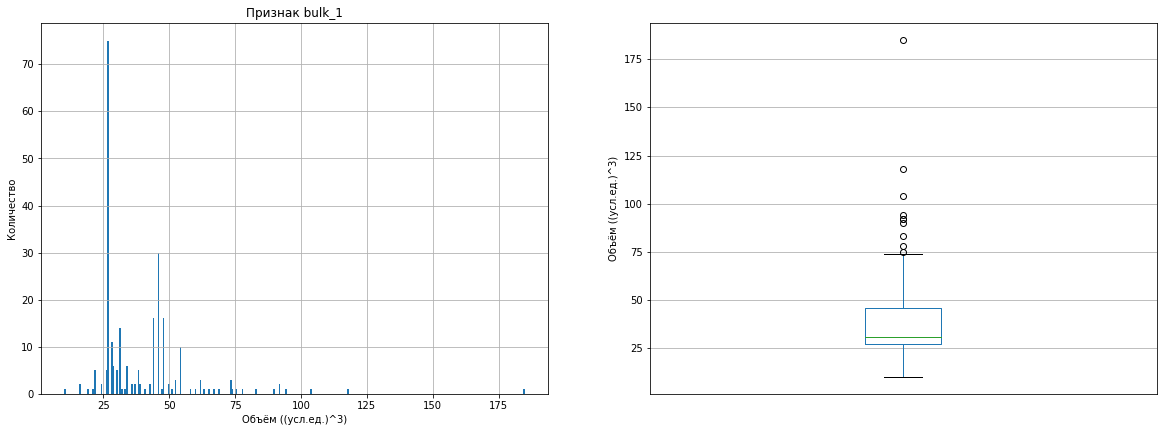

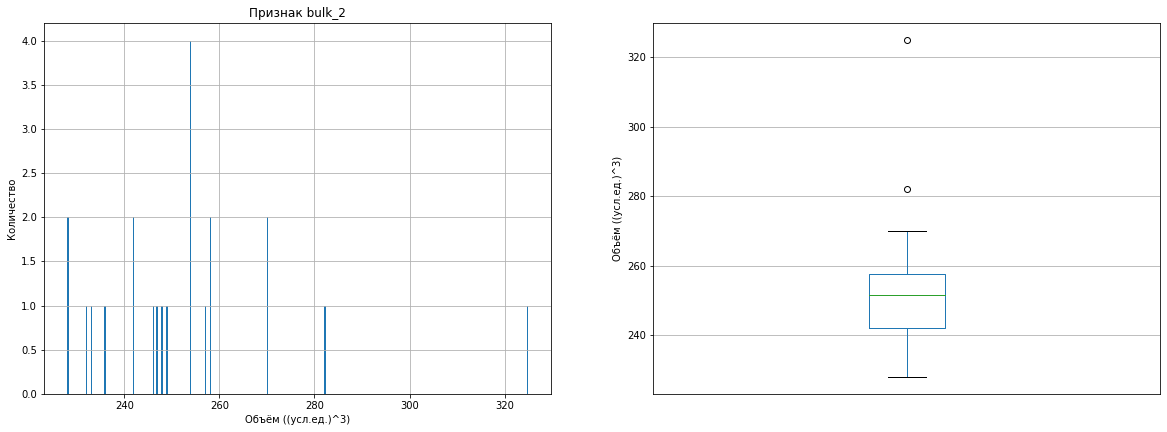

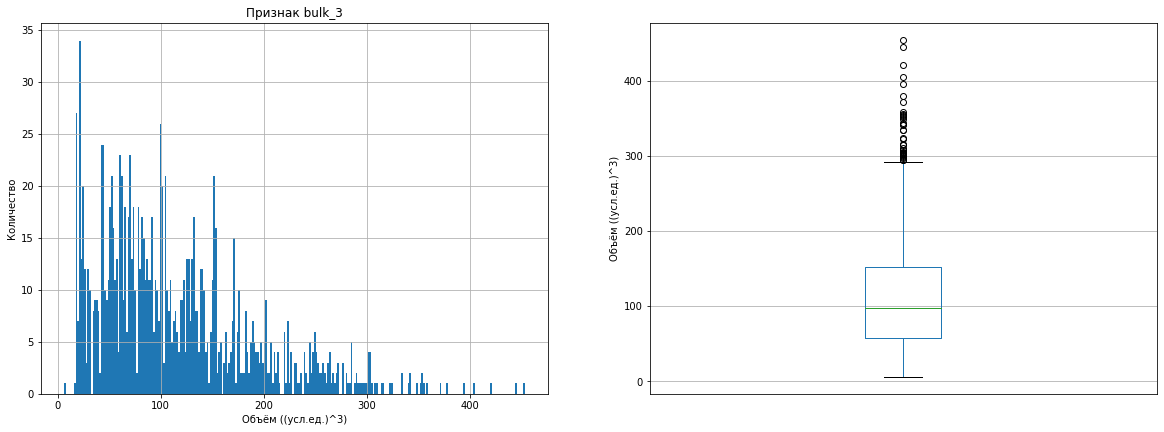

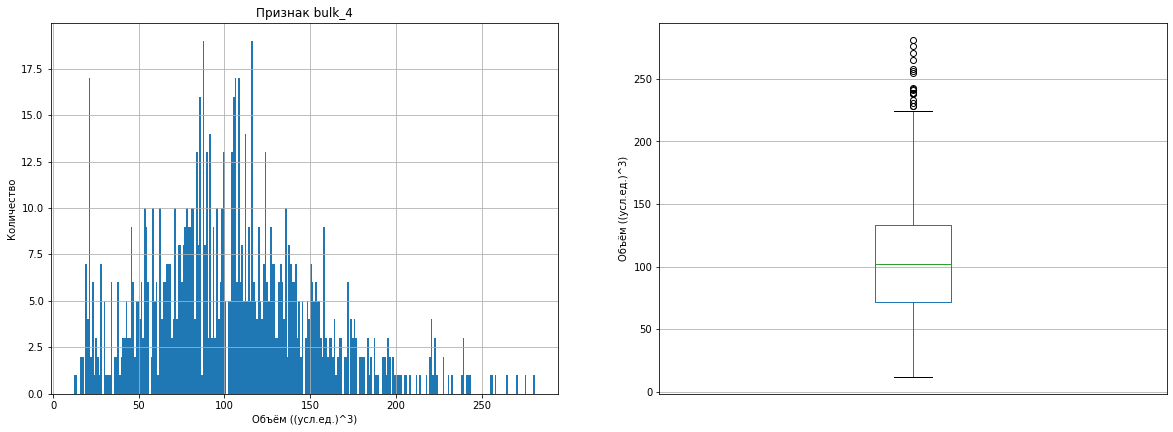

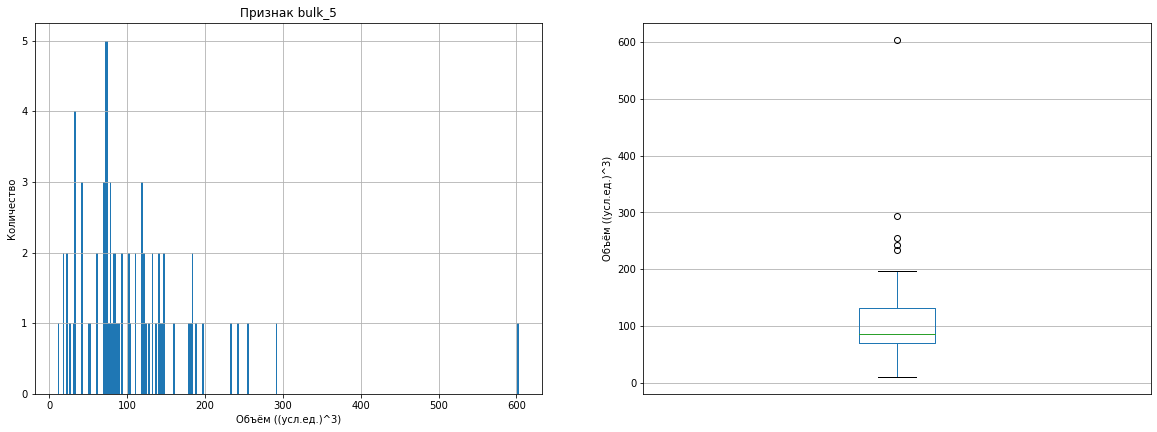

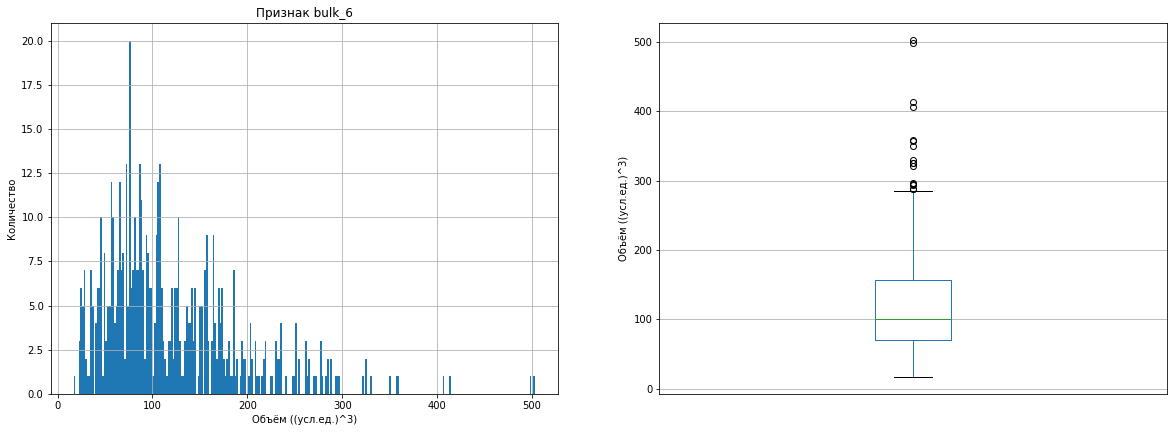

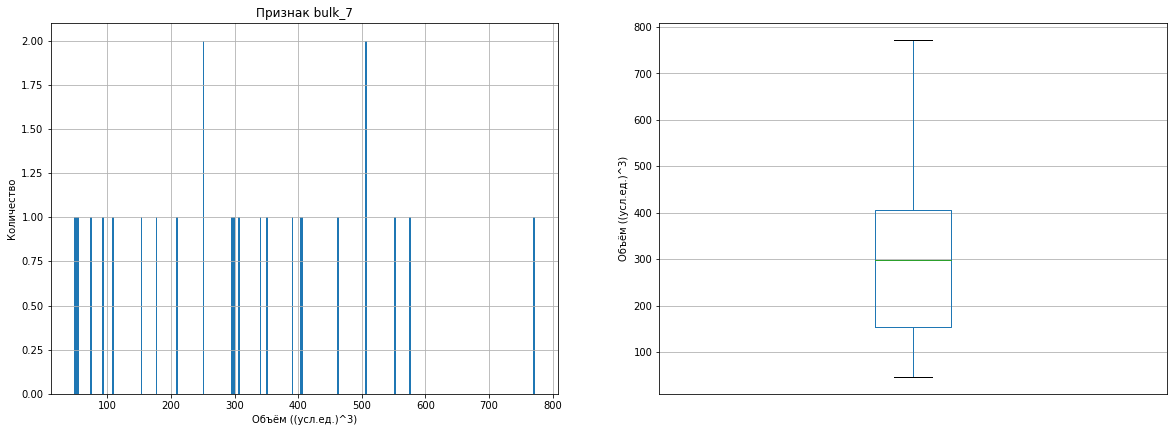

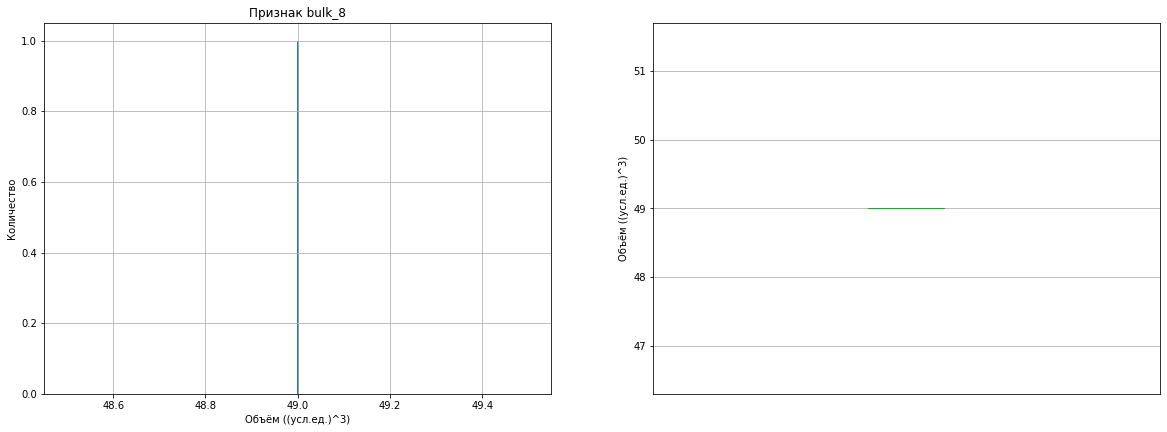

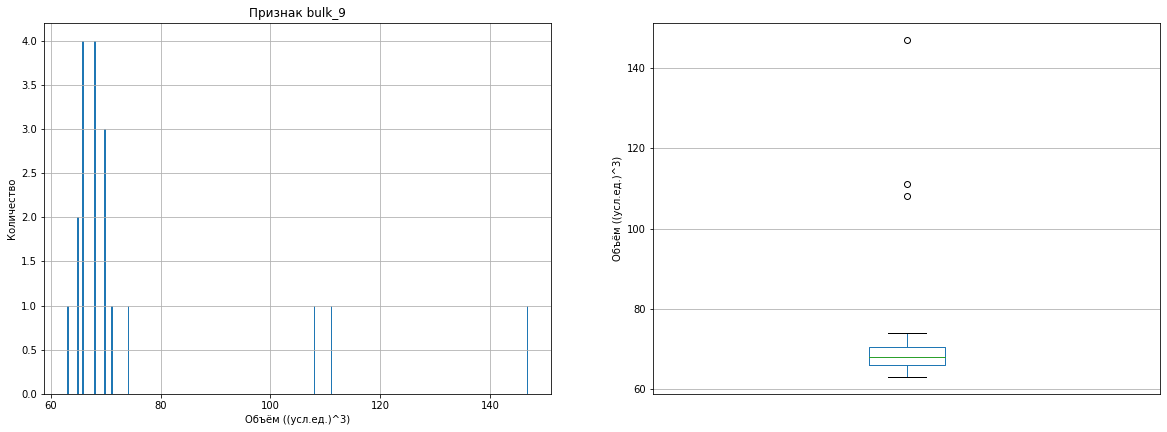

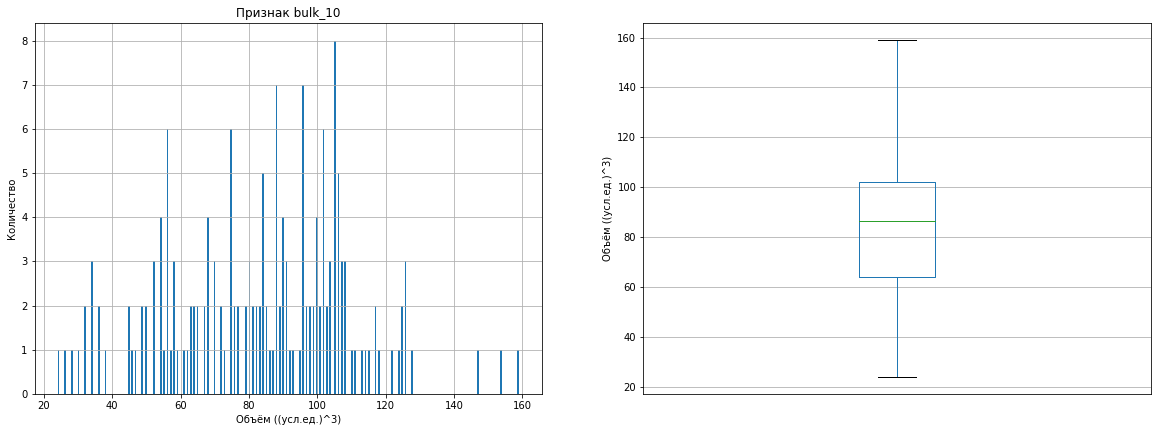

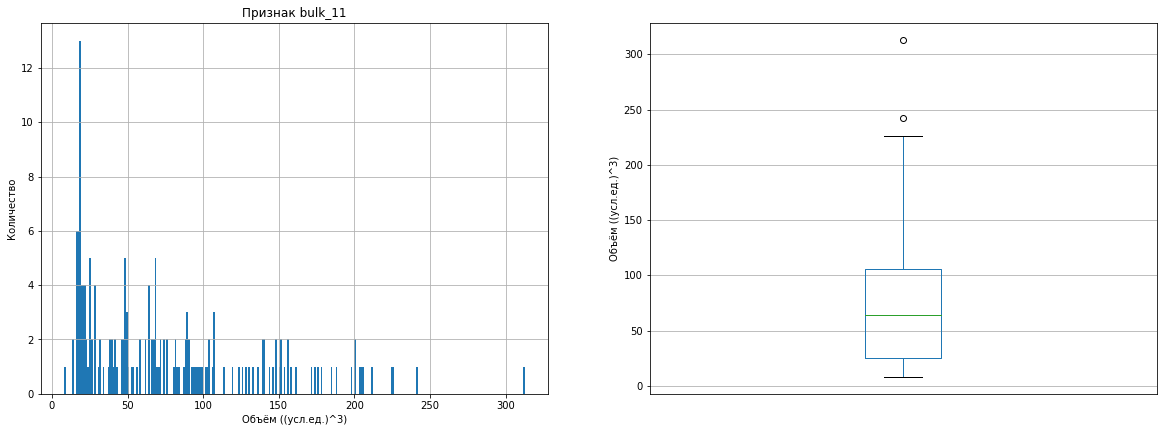

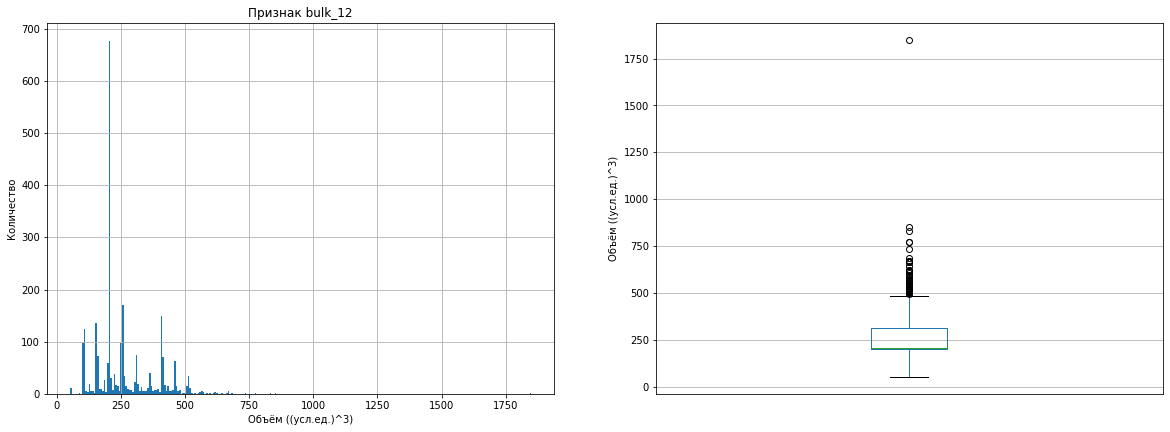

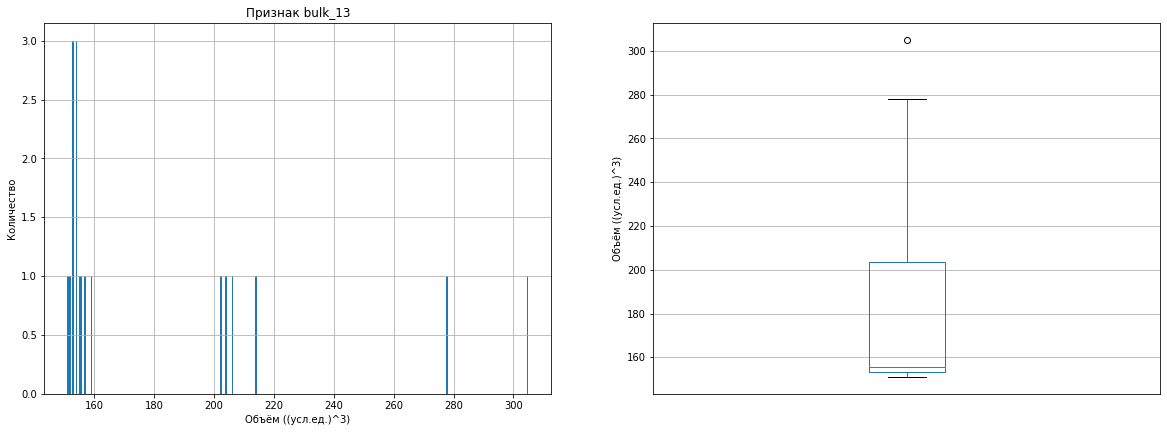

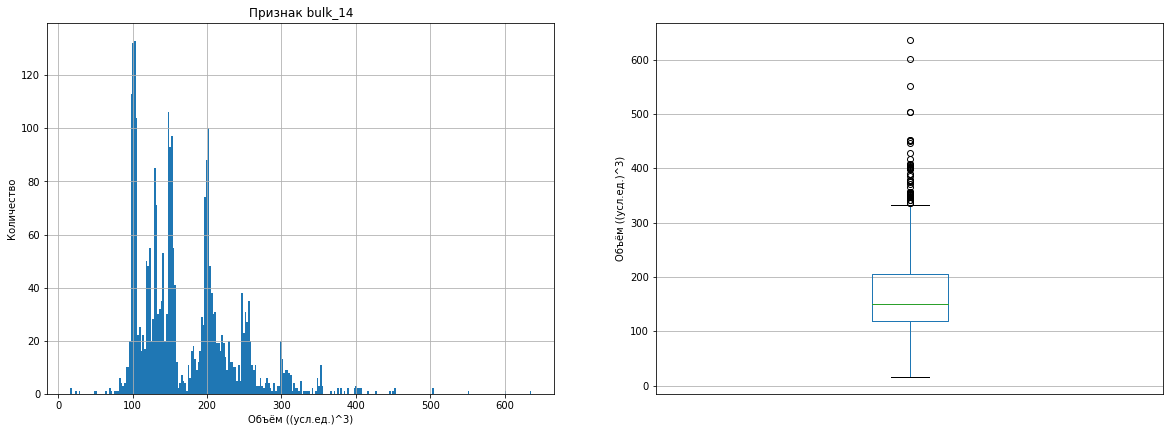

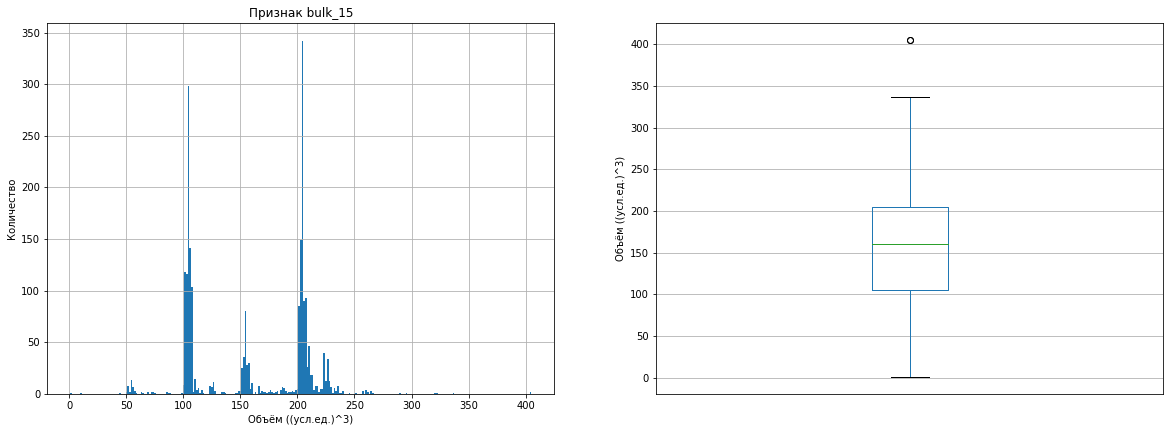

In [36]:
measure_x = ['Объём ((усл.ед.)^3)'] * 15
dataframe_count_analyse(data_bulk_new, 'data_bulk_new', measure_x)

Из результатов вывода информации также видно, что выбросы присутствуют, но их достаточно мало. В связи с этим удалять их **не будем**.

Однако при изучении гистограмм можно заметить, что какие-то материалы подаются слишком часто, а другие крайне мало; поэтомы посмотрим на количество подаваемых материалов и примем решение о продолжении их использования или нет.

Определим количество используемых материалов:

In [37]:
sorted_data_bulk_new = data_bulk_new.drop(columns = 'key').count().sort_values(ascending = False)
print('Количество использованных материалов:\n', sorted_data_bulk_new)

Количество использованных материалов:
 bulk_14    2806
bulk_12    2450
bulk_15    2248
bulk_3     1298
bulk_4     1014
bulk_6      576
bulk_1      252
bulk_11     177
bulk_10     176
bulk_5       77
bulk_7       25
bulk_2       22
bulk_9       19
bulk_13      18
bulk_8        1
dtype: int64


Выясним нижний порог для количества используемых материалов. Обычно принято, что `5 %` - это достаточно, чтобы сказать что-то о результате вычисления или погрешности вычисления. В нашей задаче возьмём процент немного выше - `7 %`, чтобы точно убедиться в том, что мы не убрали из исследования нужный материал; а также найдём минимум количества, ниже которого нельзя опускаться:

In [38]:
print('Нижний порог для количества используемого сырья в партиях установим в ', round(len(data_bulk_new)*0.07,3), 'шт.')

Нижний порог для количества используемого сырья в партиях установим в  219.03 шт.


Мы определили минимум, ниже которого нельзя опускаться, так как эти материалы используются крайне редко, что может искказить результаты. Отобразим полученные данные на графике для более наглядного восприятия:  

Text(0.5, 1.0, 'Количество использованных сыпучих материалов')

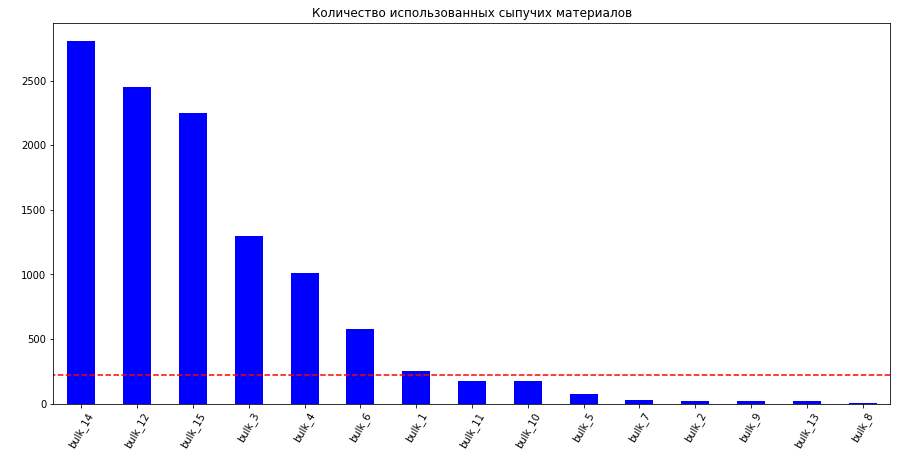

In [39]:
plt.figure(figsize = (15,7))
sorted_data_bulk_new.plot(kind='bar', color='blue')
plt.hlines(y=len(data_bulk_new)*0.07, xmin=-1, xmax=15, colors='red', linestyles='dashed')
plt.xticks(rotation=60)
plt.ylabel(' ')
plt.title('Количество использованных сыпучих материалов')

Из графика стобчатых диаграмм и нижней границы видно, что в исследовании можно оставить такие материалы, как `'bulk_1'`, `'bulk_3'`, `'bulk_4'`, `'bulk_6'`, `'bulk_12'`,`'bulk_14'`, `'bulk_15'`, так как они выше границы. Остальные же материалы мы опустим, так как их использование крайне редкое.  

Обновим данные в датасете:

In [40]:
data_bulk_new = data_bulk_new[['key','bulk_1', 'bulk_3', 'bulk_4', 'bulk_6', 'bulk_12','bulk_14', 'bulk_15']]

**Данные о подаче сыпучих материалов (время)**

Так как данный датафрейм представляет собой наличие записей о времени (временные ряды), то анализ временных рядов по подаче сыпучих материалов будет нам мало информативен и полезен. Поэтому оставим данный датафрейм без каких-либо изменений.

**Данные о продувке сплава газом**

Изучим датафрейм:

'Название датафрейма: data_gas_new'

'Общая информация и размеры датафрейма: '

(3239, 2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3239 entries, 0 to 3238
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3239 non-null   int64  
 1   gas_1   3239 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 50.7 KB


None

'Первые строки: '

,key,gas_1
0,1,29.749986
1,2,12.555561
2,3,28.554793


'Описательные характеристики датафрейма: '

,key,gas_1
count,3239.000000,3239.000000
mean,1621.861377,11.002062
std,935.386334,6.220327
min,1.000000,0.008399
25%,812.500000,7.043089
50%,1622.000000,9.836267
75%,2431.500000,13.769915
max,3241.000000,77.995040


 
Графическое представление признаков:


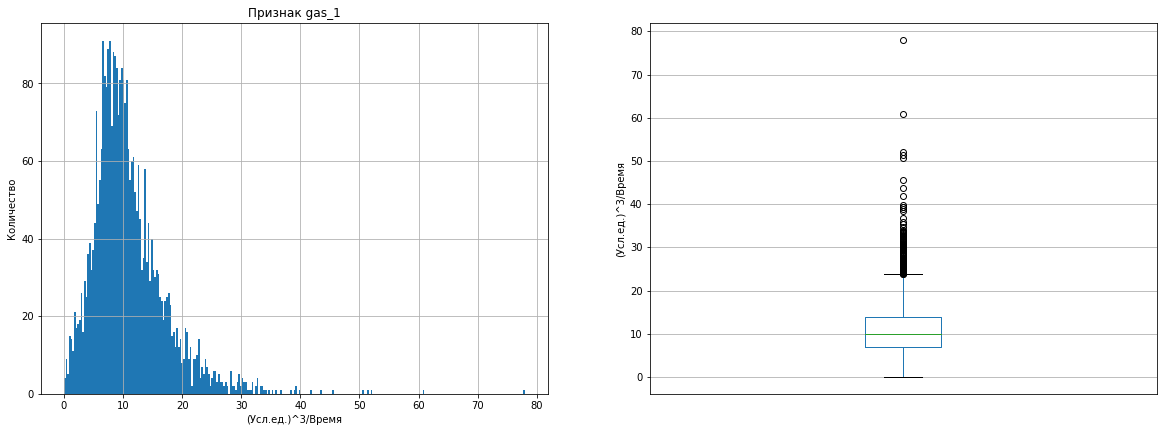

In [41]:
measure_x = ['(Усл.ед.)^3/Время']
dataframe_count_analyse(data_gas_new, 'data_gas_new', measure_x)

Из представленных диаграмм видно, что выбросов много и удалять их **не будем**, так как это может повлиять на результаты исследования. К тому же удаление может плохо сказаться, так как данные будут слишком "чистыми" и сама модель будет идеально отлажена из-за этого.

**Данные о проволочных материалах (объём)**

Изучим датафрейм:

'Название датафрейма: data_wire_new'

'Общая информация и размеры датафрейма: '

(3081, 10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3081 non-null   int64  
 1   wire_1  3055 non-null   float64
 2   wire_2  1079 non-null   float64
 3   wire_3  63 non-null     float64
 4   wire_4  14 non-null     float64
 5   wire_5  1 non-null      float64
 6   wire_6  73 non-null     float64
 7   wire_7  11 non-null     float64
 8   wire_8  19 non-null     float64
 9   wire_9  29 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 240.8 KB


None

'Первые строки: '

,key,wire_1,wire_2,wire_3,wire_4,wire_5,wire_6,wire_7,wire_8,wire_9
0,1,60.059998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,96.052315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,91.160157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


'Описательные характеристики датафрейма: '

,key,wire_1,wire_2,wire_3,wire_4,wire_5,wire_6,wire_7,wire_8,wire_9
count,3081.000000,3055.000000,1079.000000,63.000000,14.000000,1.000,73.000000,11.000000,19.000000,29.000000
mean,1623.426485,100.895853,50.577323,189.482681,57.442841,15.132,48.016974,10.039007,53.625193,34.155752
std,932.996726,42.012518,39.320216,99.513444,28.824667,NaN,33.919845,8.610584,16.881728,19.931616
min,1.000000,1.918800,0.030160,0.144144,24.148801,15.132,0.034320,0.234208,45.076721,4.622800
25%,823.000000,72.115684,20.193680,95.135044,40.807002,15.132,25.053600,6.762756,46.094879,22.058401
50%,1619.000000,100.158234,40.142956,235.194977,45.234282,15.132,42.076324,9.017009,46.279999,30.066399
75%,2434.000000,126.060483,70.227558,276.252014,76.124619,15.132,64.212723,11.886057,48.089603,43.862003
max,3241.000000,330.314424,282.780152,385.008668,113.231044,15.132,180.454575,32.847674,102.762401,90.053604


 
Графическое представление признаков:


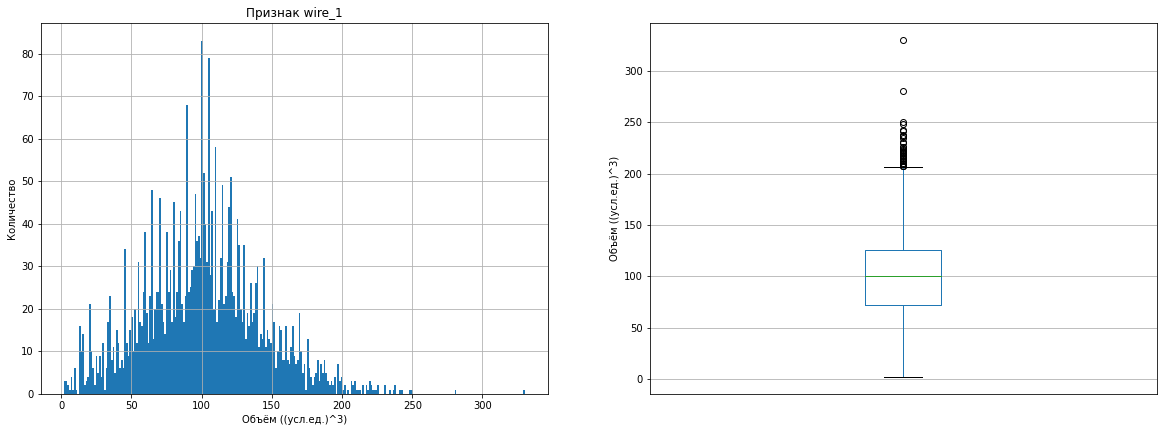

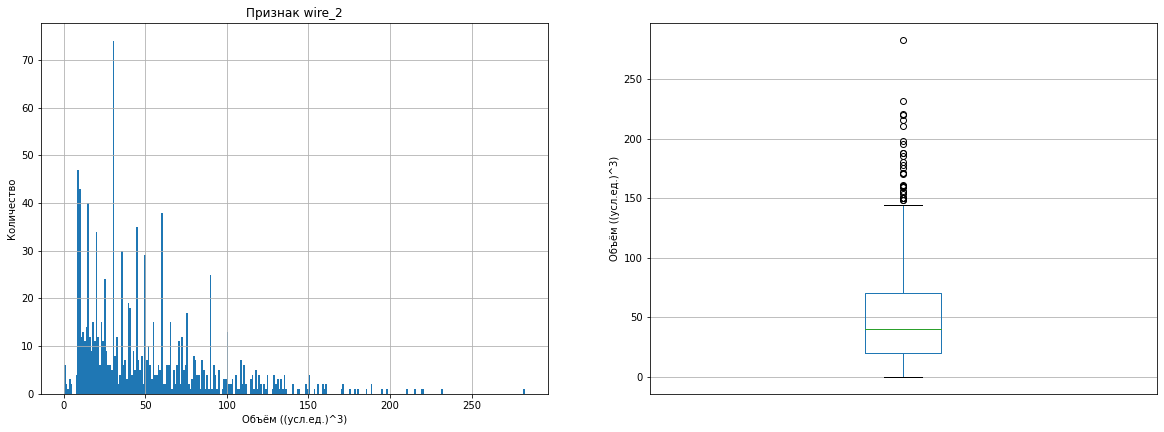

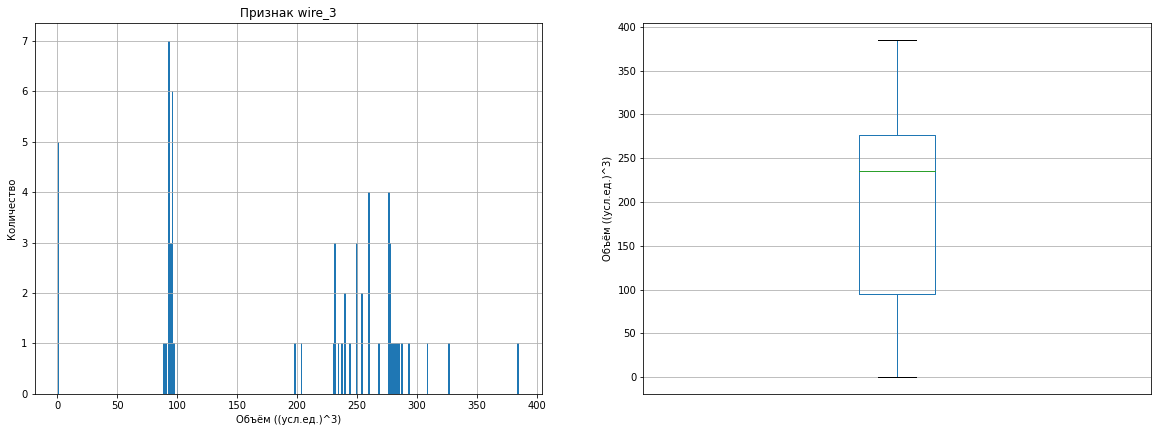

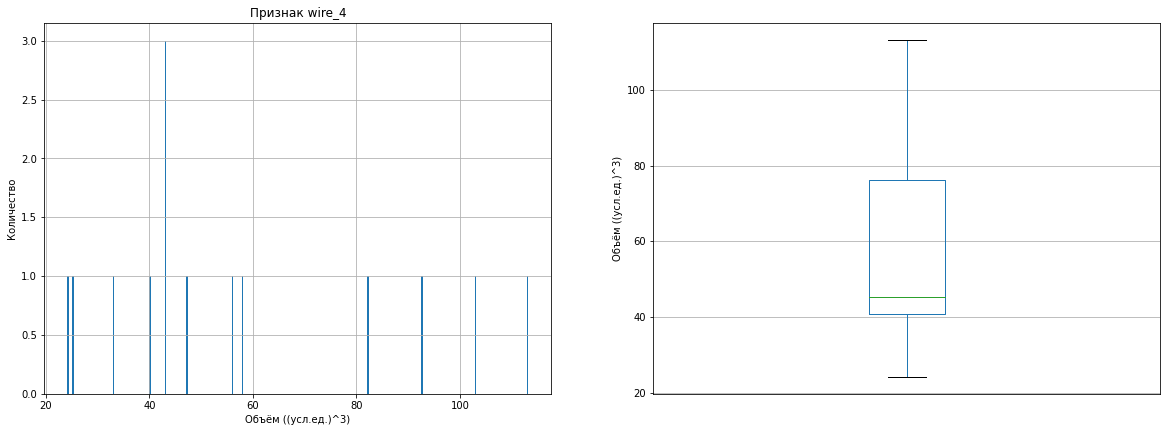

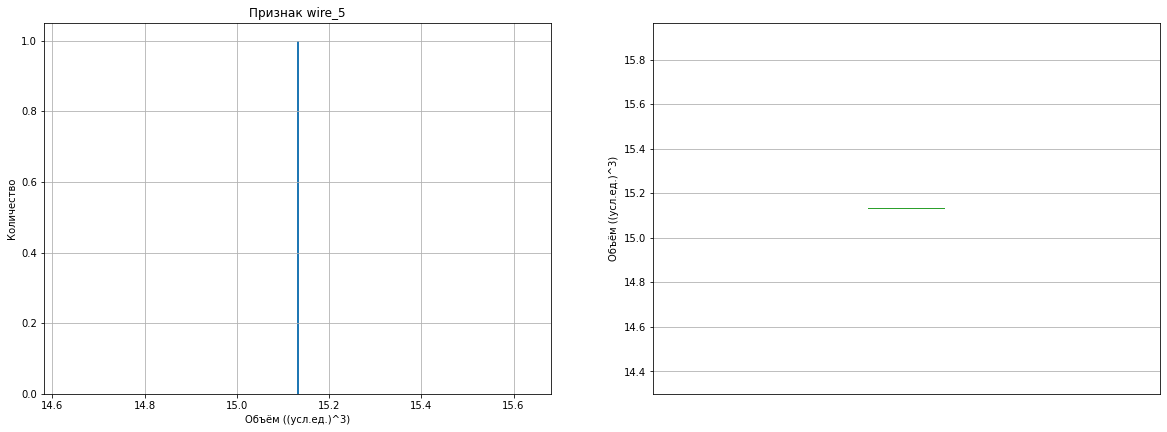

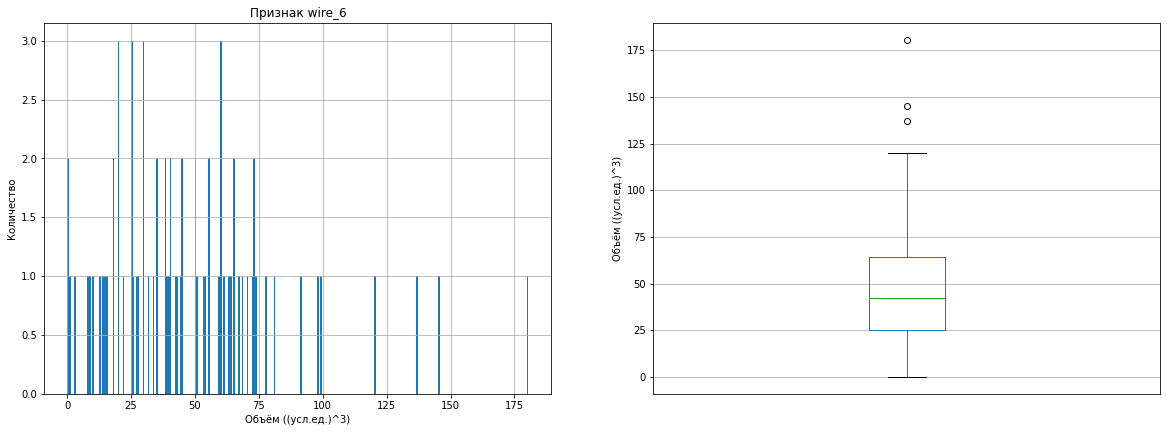

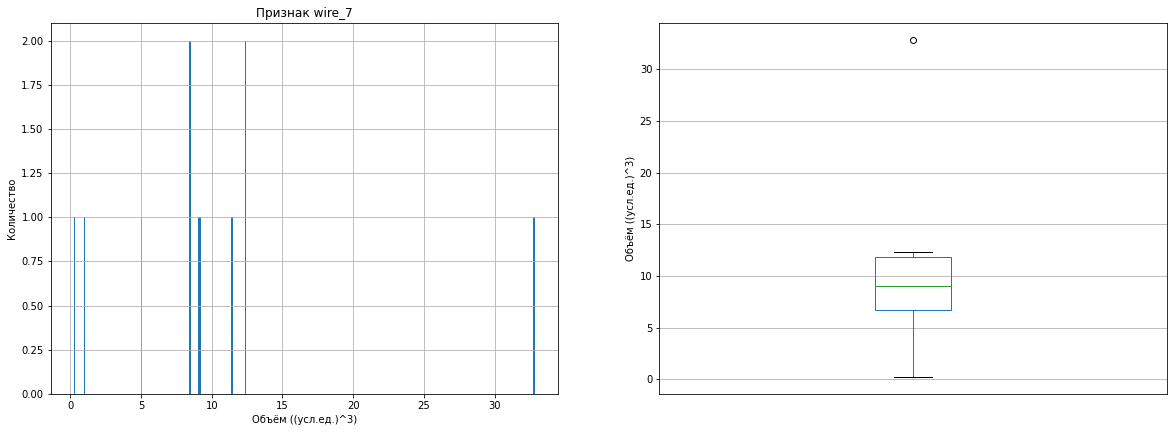

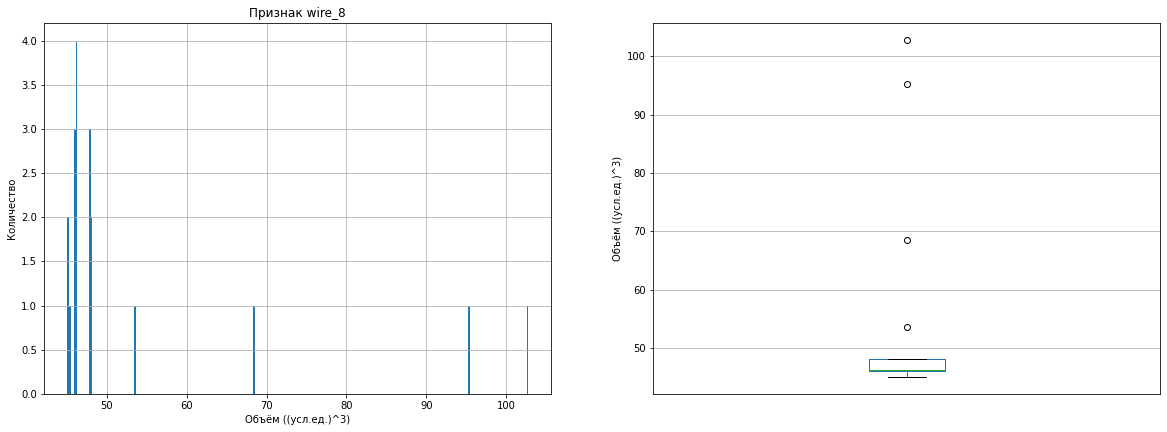

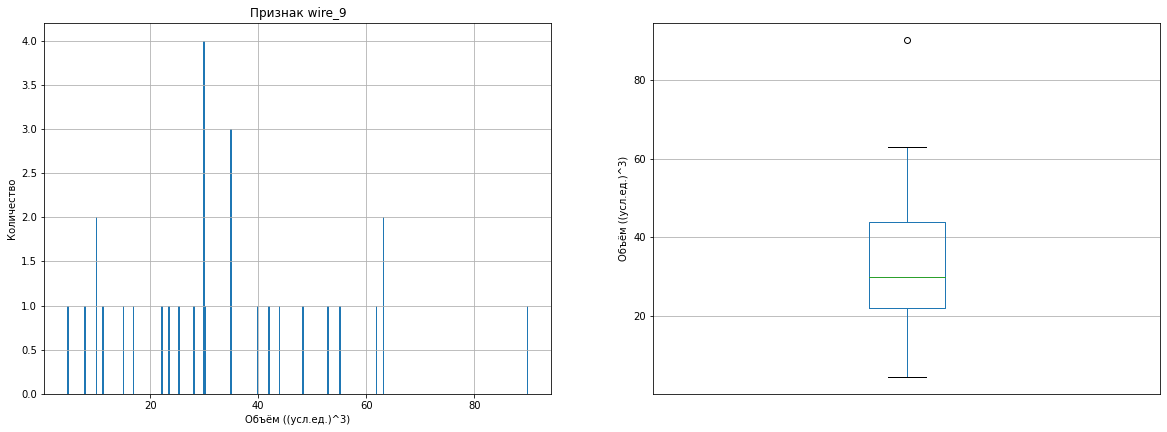

In [42]:
measure_x = ['Объём ((усл.ед.)^3)'] * 9
dataframe_count_analyse(data_wire_new, 'data_wire_new', measure_x)

Из результатов вывода информации также видно, что выбросы присутствуют, но их достаточно мало. В связи с этим удалять их **не будем**.

Однако при изучении гистограмм можно заметить, что какие-то материалы подаются слишком часто, а другие крайне мало; поэтомы посмотрим на количество подаваемых материалов и примем решение о продолжении их использования или нет.

Определим количество используемых материалов:

In [43]:
sorted_data_wire_new = data_wire_new.drop(columns = 'key').count().sort_values(ascending = False)
print('Количество использованных материалов:\n', sorted_data_wire_new)

Количество использованных материалов:
 wire_1    3055
wire_2    1079
wire_6      73
wire_3      63
wire_9      29
wire_8      19
wire_4      14
wire_7      11
wire_5       1
dtype: int64


Выясним нижний порог для количества используемых материалов. Обычно принято, что `5 %` - это достаточно, чтобы сказать что-то о результате вычисления или погрешности вычисления. В нашей задаче возьмём процент немного выше - `7 %`, чтобы точно убедиться в том, что мы не убрали из исследования нужный материал; а также найдём минимум количества, ниже которого нельзя опускаться:

In [44]:
print('Нижний порог для количества используемого сырья в партиях установим в ', round(len(data_wire_new)*0.07,3), 'шт.')

Нижний порог для количества используемого сырья в партиях установим в  215.67 шт.


Мы определили минимум, ниже которого нельзя опускаться, так как эти материалы используются крайне редко, что может искказить результаты. Отобразим полученные данные на графике для более наглядного восприятия: 

Text(0.5, 1.0, 'Количество использованных проволочных материалов')

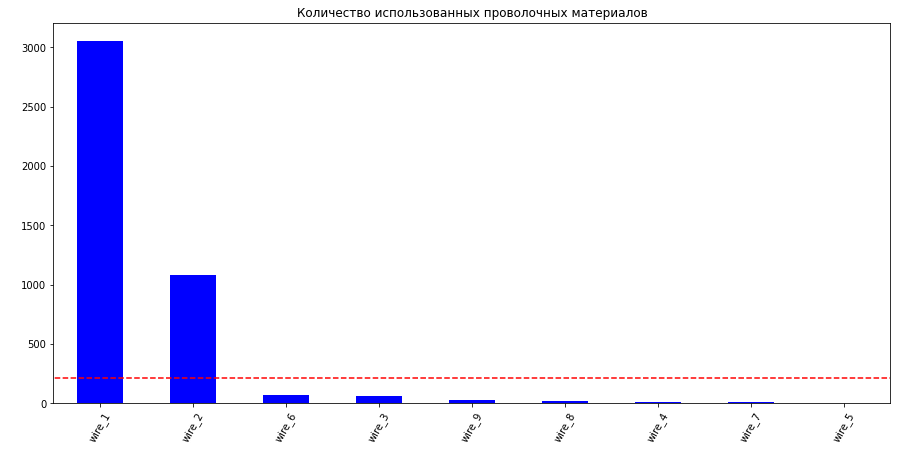

In [45]:
plt.figure(figsize = (15,7))
sorted_data_wire_new.plot(kind='bar', color='blue')
plt.hlines(y=len(data_wire_new)*0.07, xmin=-1, xmax=15, colors='red', linestyles='dashed')
plt.xticks(rotation=60)
plt.ylabel(' ')
plt.title('Количество использованных проволочных материалов')

Из графика стобчатых диаграмм и нижней границы видно, что в исследовании можно оставить такие материалы, как `'wire_1'`, `'wire_2'`, так как они выше границы. Остальные же материалы мы опустим, так как их использование крайне редкое.  

Обновим данные в датасете:

In [46]:
data_wire_new = data_wire_new[['key','wire_1','wire_2']]

**Данные о проволочных материалах (время)**

Так как данный датафрейм представляет собой наличие записей о времени (временные ряды), то анализ временных рядов по подаче проволочных материалов будет нам мало информативен и полезен. Поэтому оставим данный датафрейм без каких-либо изменений.

**Результаты измерения температуры**

Изучим датафрейм:

'Название датафрейма: data_temp_new'

'Общая информация и размеры датафрейма: '

(18092, 3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18092 entries, 0 to 18091
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   key               18092 non-null  int64         
 1   measurement_time  18092 non-null  datetime64[ns]
 2   temperature       14665 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 424.2 KB


None

'Первые строки: '

,key,measurement_time,temperature
0,1,2019-05-03 11:02:04,1571.0
1,1,2019-05-03 11:07:18,1604.0
2,1,2019-05-03 11:11:34,1618.0


'Описательные характеристики датафрейма: '

,key,temperature
count,18092.000000,14665.000000
mean,1616.460977,1590.722741
std,934.641385,20.394381
min,1.000000,1191.000000
25%,807.750000,1580.000000
50%,1618.000000,1590.000000
75%,2429.000000,1599.000000
max,3241.000000,1705.000000


 
Графическое представление признаков:


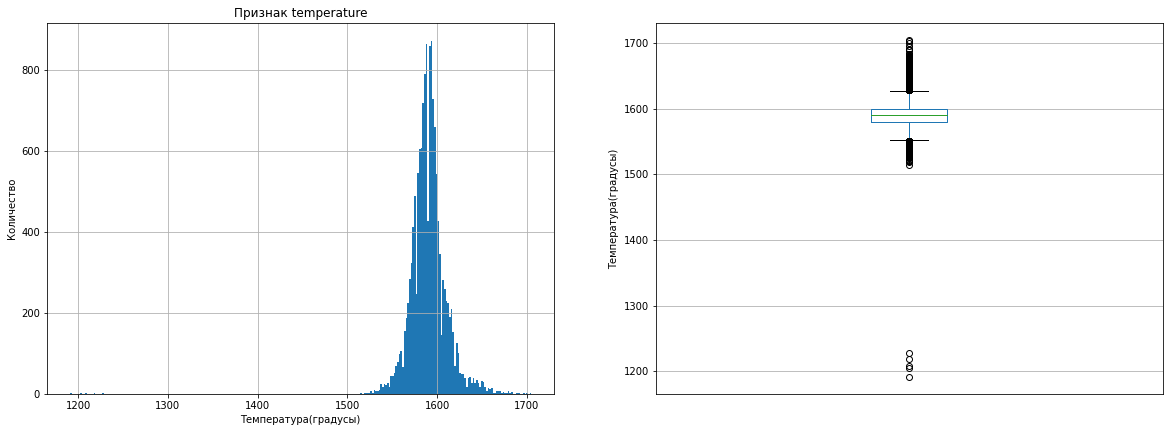

In [47]:
measure_x = ['Температура(градусы)']
dataframe_count_analyse(data_temp_new, 'data_temp_new', measure_x)

В результате изучения конкретно виден выброс в признаке `temperature`; нами было определено, что в рассматриваемых нами материалах происходят физико-химические процессы при температуре не менее 1400 градусов, поэтому всё что ниже этой температуры, мы можем удалить:

In [48]:
data_temp_new = data_temp_new.query('temperature >= 1400')

Повторно выведем информацию:

'Название датафрейма: data_temp_new'

'Общая информация и размеры датафрейма: '

(14660, 3)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 14660 entries, 0 to 18086
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   key               14660 non-null  int64         
 1   measurement_time  14660 non-null  datetime64[ns]
 2   temperature       14660 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 458.1 KB


None

'Первые строки: '

,key,measurement_time,temperature
0,1,2019-05-03 11:02:04,1571.0
1,1,2019-05-03 11:07:18,1604.0
2,1,2019-05-03 11:11:34,1618.0


'Описательные характеристики датафрейма: '

,key,temperature
count,14660.000000,14660.000000
mean,1325.369236,1590.852729
std,787.407873,19.143141
min,1.000000,1515.000000
25%,654.000000,1580.000000
50%,1314.000000,1590.000000
75%,1962.250000,1599.000000
max,3241.000000,1705.000000


 
Графическое представление признаков:


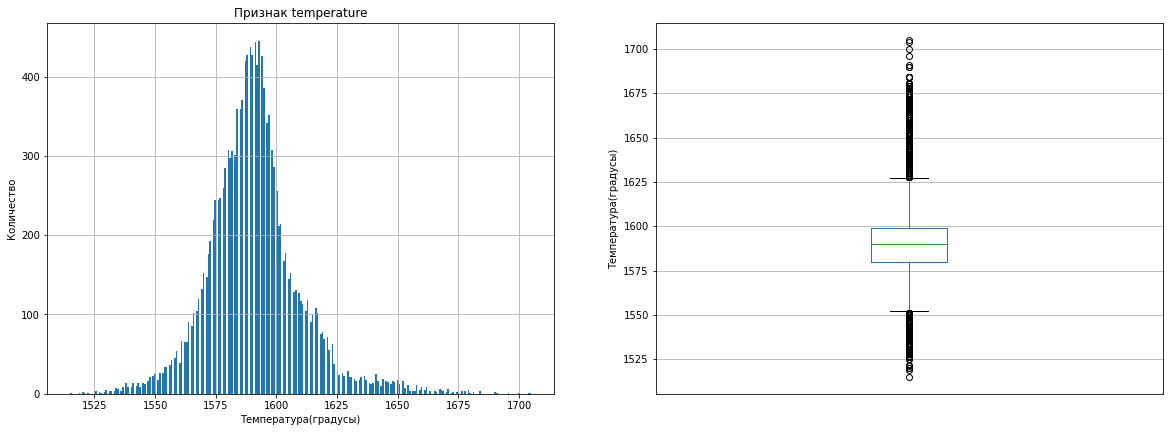

In [49]:
measure_x = ['Температура(градусы)']
dataframe_count_analyse(data_temp_new, 'data_temp_new', measure_x)

Как видно гистограмма похожа на нормальное распределение. Также из "ящика с усами" мы видим большое число выбросов в данных; такое количество данных точно нельзя удалять, так как это может плохо отразиться на результатах исследования.

Как известно изменений для температуры - её изменение - проводится несколько раз, то есть количество разных температур для одной партии должно быть больше, чем 2; поэтому посмотрим сколько раз изменялась температура для партий:

In [50]:
data_temp_new_add = data_temp_new.groupby('key').agg(count_rise_temp = ('temperature', 'count'), \
                                 measurement_time_first = ('measurement_time','first'),\
                                 measurement_time_last = ('measurement_time','last'), \
                                 all_temperature = ('temperature', list)).reset_index()

In [51]:
data_temp_new_add

,key,count_rise_temp,measurement_time_first,measurement_time_last,all_temperature
0,1,6,2019-05-03 11:02:04,2019-05-03 11:30:38,"[1571.0, 1604.0, 1618.0, 1601.0, 1606.0, 1613.0]"
1,2,5,2019-05-03 11:34:04,2019-05-03 11:55:09,"[1581.0, 1577.0, 1589.0, 1604.0, 1602.0]"
2,3,6,2019-05-03 12:06:44,2019-05-03 12:35:57,"[1596.0, 1597.0, 1598.0, 1599.0, 1600.0, 1599.0]"
3,4,5,2019-05-03 12:39:27,2019-05-03 12:59:47,"[1601.0, 1623.0, 1618.0, 1617.0, 1625.0]"
4,5,5,2019-05-03 13:11:03,2019-05-03 13:36:39,"[1576.0, 1592.0, 1589.0, 1586.0, 1602.0]"
...,...,...,...,...,...
3210,3237,1,2019-09-06 11:31:15,2019-09-06 11:31:15,[1569.0]
3211,3238,1,2019-09-06 12:16:15,2019-09-06 12:16:15,[1584.0]
3212,3239,1,2019-09-06 14:16:50,2019-09-06 14:16:50,[1598.0]
3213,3240,1,2019-09-06 15:25:21,2019-09-06 15:25:21,[1617.0]


Сделаем срез данных по количеству изменений температуры больше 2, так как это необходимо для сплава рассматриваемой партии:

In [52]:
data_temp_new_add = data_temp_new_add.query('count_rise_temp > 2')

Рассмотрим последние строки датафрйема, чтобы убедиться в правильности среза данных:

In [53]:
data_temp_new_add.sort_values(by='count_rise_temp', ascending=False).tail()

,key,count_rise_temp,measurement_time_first,measurement_time_last,all_temperature
871,883,3,2019-06-06 19:31:55,2019-06-06 19:44:42,"[1606.0, 1602.0, 1599.0]"
1519,1534,3,2019-06-30 09:10:39,2019-06-30 09:26:06,"[1633.0, 1620.0, 1605.0]"
1793,1808,3,2019-07-09 14:34:30,2019-07-09 14:54:21,"[1608.0, 1596.0, 1597.0]"
1078,1090,3,2019-06-14 06:26:44,2019-06-14 06:54:58,"[1600.0, 1586.0, 1608.0]"
105,108,3,2019-05-07 09:50:20,2019-05-07 10:02:56,"[1619.0, 1610.0, 1597.0]"


Срез необходимых данных произошел успешно.

Вычислим разницу по времени для нагрева и запишем в датафрейм, а также запишем начальную, следующую за ней(вторую) и конечную температуры:

In [54]:
data_temp_new_add['measurement_time_difference'] = data_temp_new_add['measurement_time_last'] - data_temp_new_add['measurement_time_first'] 

/tmp/ipykernel_217/2898716454.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_temp_new_add['measurement_time_difference'] = data_temp_new_add['measurement_time_last'] - data_temp_new_add['measurement_time_first']


In [55]:
data_temp_new_add['start_temperature'] = data_temp_new_add['all_temperature'].apply(lambda x: x[0])
data_temp_new_add['second_temperature'] = data_temp_new_add['all_temperature'].apply(lambda x: x[1])
data_temp_new_add['end_temperature'] = data_temp_new_add['all_temperature'].apply(lambda x: x[-1])
data_temp_new_add = data_temp_new_add.drop(columns = 'all_temperature')

/tmp/ipykernel_217/511316292.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_temp_new_add['start_temperature'] = data_temp_new_add['all_temperature'].apply(lambda x: x[0])
/tmp/ipykernel_217/511316292.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_temp_new_add['second_temperature'] = data_temp_new_add['all_temperature'].apply(lambda x: x[1])
/tmp/ipykernel_217/511316292.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_ind

Сделаем копию нового датафрейма в старый и отобразим результаты записи:

In [56]:
data_temp_new = data_temp_new_add.copy()

In [57]:
data_temp_new

,key,count_rise_temp,measurement_time_first,measurement_time_last,measurement_time_difference,start_temperature,second_temperature,end_temperature
0,1,6,2019-05-03 11:02:04,2019-05-03 11:30:38,0 days 00:28:34,1571.0,1604.0,1613.0
1,2,5,2019-05-03 11:34:04,2019-05-03 11:55:09,0 days 00:21:05,1581.0,1577.0,1602.0
2,3,6,2019-05-03 12:06:44,2019-05-03 12:35:57,0 days 00:29:13,1596.0,1597.0,1599.0
3,4,5,2019-05-03 12:39:27,2019-05-03 12:59:47,0 days 00:20:20,1601.0,1623.0,1625.0
4,5,5,2019-05-03 13:11:03,2019-05-03 13:36:39,0 days 00:25:36,1576.0,1592.0,1602.0
...,...,...,...,...,...,...,...,...
2472,2495,5,2019-08-10 11:27:47,2019-08-10 11:50:47,0 days 00:23:00,1570.0,1590.0,1591.0
2473,2496,7,2019-08-10 11:56:48,2019-08-10 12:25:13,0 days 00:28:25,1554.0,1576.0,1591.0
2474,2497,4,2019-08-10 12:37:26,2019-08-10 12:53:28,0 days 00:16:02,1571.0,1577.0,1589.0
2475,2498,6,2019-08-10 12:58:11,2019-08-10 13:23:31,0 days 00:25:20,1591.0,1570.0,1594.0


### Сделаем выводы о данных

В результате исследовательского анализа было проведено следующее:
- изучили общую информацию о датафреймах и выявили неточности, которые нужно устранить
- привели названия столбцов к "правильной" записи (строчные буквы, латинский алфавит, змеевидная запись)
- преобразовали типы данных столбцов с датой и временем от `object` к `datetime`
- проверили данные на наличие пропусков
- приняли решение **не удалять** пропуски, так как их критически много, что может полностью исказить результаты исследования
- проверили данные на дубликаты и выяснили, что их нет
- провели углубленный анализ данных
- проанализировали гистограммы и диаграммы размаха для каждого датафрейма
- было проведено исследование на удаление или сохранение выбросов в результате которого было принято решение **не удалять** выбросы, так как не все графики имеют нормальное распределение, у некоторых либо крайне мало, либо крайне много выбросов, что может повлиять на результаты исследования, также идеально отлаженная модель может плохо работать на новых данных
- добавили новые признаки в некоторые датафреймы

## Объеденим признаки в один датафрейм

Проведём объединение общих данных в один датафрейм по одному ключу `key`, а также будем учитывать их объединения с учетом присутствия во всех объединяемых датасетах:

In [58]:
dataframe_list = [data_arc_new, data_bulk_new, data_gas_new, data_wire_new]
all_data = data_temp_new.copy()

In [59]:
for df in dataframe_list:
    all_data = all_data.merge(df, on='key', how='inner')

Выведем первые строки и общую информацию по объединенному датафрейму:

In [60]:
all_data.head()

,key,count_rise_temp,measurement_time_first,measurement_time_last,measurement_time_difference,start_temperature,second_temperature,end_temperature,sum_power,bulk_1,bulk_3,bulk_4,bulk_6,bulk_12,bulk_14,bulk_15,gas_1,wire_1,wire_2
0,1,6,2019-05-03 11:02:04,2019-05-03 11:30:38,0 days 00:28:34,1571.0,1604.0,1613.0,3.718736,NaN,NaN,43.0,NaN,206.0,150.0,154.0,29.749986,60.059998,NaN
1,2,5,2019-05-03 11:34:04,2019-05-03 11:55:09,0 days 00:21:05,1581.0,1577.0,1602.0,2.588349,NaN,NaN,73.0,NaN,206.0,149.0,154.0,12.555561,96.052315,NaN
2,3,6,2019-05-03 12:06:44,2019-05-03 12:35:57,0 days 00:29:13,1596.0,1597.0,1599.0,5.019223,NaN,NaN,34.0,NaN,205.0,152.0,153.0,28.554793,91.160157,NaN
3,4,5,2019-05-03 12:39:27,2019-05-03 12:59:47,0 days 00:20:20,1601.0,1623.0,1625.0,3.400038,NaN,NaN,81.0,NaN,207.0,153.0,154.0,18.841219,89.063515,NaN
4,5,5,2019-05-03 13:11:03,2019-05-03 13:36:39,0 days 00:25:36,1576.0,1592.0,1602.0,2.816980,NaN,NaN,78.0,NaN,203.0,151.0,152.0,5.413692,89.238236,9.11456


In [61]:
dataframe_info([all_data], ['all_data'])

'Название датафрейма: all_data'

'Размеры датафрейма: '

(2303, 19)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2303 entries, 0 to 2302
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype          
---  ------                       --------------  -----          
 0   key                          2303 non-null   int64          
 1   count_rise_temp              2303 non-null   int64          
 2   measurement_time_first       2303 non-null   datetime64[ns] 
 3   measurement_time_last        2303 non-null   datetime64[ns] 
 4   measurement_time_difference  2303 non-null   timedelta64[ns]
 5   start_temperature            2303 non-null   float64        
 6   second_temperature           2303 non-null   float64        
 7   end_temperature              2303 non-null   float64        
 8   sum_power                    2303 non-null   float64        
 9   bulk_1                       199 non-null    float64        
 10  bulk_3                       951 non-null    float64        
 11  bulk_4                       8

None

Из результатов видно, что объединение произошло успешно: каждому ковшу соответствуют свои данные.

## Предобработка и исследовательский анализ объединенного датафрейма

Выведем первые строки объединенного датафрейма, чтобы понять, какие действия необходимо совершить с ним:

In [62]:
all_data.head()

,key,count_rise_temp,measurement_time_first,measurement_time_last,measurement_time_difference,start_temperature,second_temperature,end_temperature,sum_power,bulk_1,bulk_3,bulk_4,bulk_6,bulk_12,bulk_14,bulk_15,gas_1,wire_1,wire_2
0,1,6,2019-05-03 11:02:04,2019-05-03 11:30:38,0 days 00:28:34,1571.0,1604.0,1613.0,3.718736,NaN,NaN,43.0,NaN,206.0,150.0,154.0,29.749986,60.059998,NaN
1,2,5,2019-05-03 11:34:04,2019-05-03 11:55:09,0 days 00:21:05,1581.0,1577.0,1602.0,2.588349,NaN,NaN,73.0,NaN,206.0,149.0,154.0,12.555561,96.052315,NaN
2,3,6,2019-05-03 12:06:44,2019-05-03 12:35:57,0 days 00:29:13,1596.0,1597.0,1599.0,5.019223,NaN,NaN,34.0,NaN,205.0,152.0,153.0,28.554793,91.160157,NaN
3,4,5,2019-05-03 12:39:27,2019-05-03 12:59:47,0 days 00:20:20,1601.0,1623.0,1625.0,3.400038,NaN,NaN,81.0,NaN,207.0,153.0,154.0,18.841219,89.063515,NaN
4,5,5,2019-05-03 13:11:03,2019-05-03 13:36:39,0 days 00:25:36,1576.0,1592.0,1602.0,2.816980,NaN,NaN,78.0,NaN,203.0,151.0,152.0,5.413692,89.238236,9.11456


### Преобразование столбцов типа данных datetime

В связи с некоторыми особенностями дальнейших действия, таких как корреляционный анализ и обучение моделей, приведем время к числовому формату Unix-время, чтобы избежать ошибок и некорректностей при построении модели:

In [63]:
# список столбцов типа datetime
time_col = ['measurement_time_first', 'measurement_time_last', 'measurement_time_difference']

In [64]:
# преобразование столбцов с типом datetime64 в числовой формат Unix-время
all_data[time_col] = all_data[time_col].astype(int) / 10**9

Выведем перввые строки, чтобы проверить изменения:

In [65]:
all_data.head()

,key,count_rise_temp,measurement_time_first,measurement_time_last,measurement_time_difference,start_temperature,second_temperature,end_temperature,sum_power,bulk_1,bulk_3,bulk_4,bulk_6,bulk_12,bulk_14,bulk_15,gas_1,wire_1,wire_2
0,1,6,1.556881e+09,1.556883e+09,1714.0,1571.0,1604.0,1613.0,3.718736,NaN,NaN,43.0,NaN,206.0,150.0,154.0,29.749986,60.059998,NaN
1,2,5,1.556883e+09,1.556885e+09,1265.0,1581.0,1577.0,1602.0,2.588349,NaN,NaN,73.0,NaN,206.0,149.0,154.0,12.555561,96.052315,NaN
2,3,6,1.556885e+09,1.556887e+09,1753.0,1596.0,1597.0,1599.0,5.019223,NaN,NaN,34.0,NaN,205.0,152.0,153.0,28.554793,91.160157,NaN
3,4,5,1.556887e+09,1.556888e+09,1220.0,1601.0,1623.0,1625.0,3.400038,NaN,NaN,81.0,NaN,207.0,153.0,154.0,18.841219,89.063515,NaN
4,5,5,1.556889e+09,1.556891e+09,1536.0,1576.0,1592.0,1602.0,2.816980,NaN,NaN,78.0,NaN,203.0,151.0,152.0,5.413692,89.238236,9.11456


Изменения успешно проведены.

### Проверим наличие пропусков в объединенных данных

Воспользуемся ранее написанной функцией `dataframe_skip()`, для поиска пропусков: 

In [66]:
dataframe_skip(all_data, 'all_data')

'Название датафрейма: all_data'

'Размеры датафрейма: '

(2303, 19)

key                               0
count_rise_temp                   0
measurement_time_first            0
measurement_time_last             0
measurement_time_difference       0
start_temperature                 0
second_temperature                0
end_temperature                   0
sum_power                         0
bulk_1                         2104
bulk_3                         1352
bulk_4                         1499
bulk_6                         1871
bulk_12                         495
bulk_14                         241
bulk_15                         607
gas_1                             0
wire_1                           22
wire_2                         1505
dtype: int64

Процентное соотношение количества пропусков к общему числу данных:
 key                             0.000
count_rise_temp                 0.000
measurement_time_first          0.000
measurement_time_last           0.000
measurement_time_difference     0.000
start_temperature               0.000
second_temperature              0.000
end_temperature                 0.000
sum_power                       0.000
bulk_1                         91.359
bulk_3                         58.706
bulk_4                         65.089
bulk_6                         81.242
bulk_12                        21.494
bulk_14                        10.465
bulk_15                        26.357
gas_1                           0.000
wire_1                          0.955
wire_2                         65.350
dtype: float64
 


В результате видим пропуски только в сыпучих (`bulk`) и проволочных (`wire`) материалах. Как мы раньше отметили, некоторые материалы используются в разных сплавах с разными пропорциями, то есть там, где пропуск по значению, можно говорить, что материал не был использован, то есть мы можем заполнить такие ячейки `0`. 

Заполним столбцы с такими данными соответствующим значением:

In [67]:
# список столбцов материалов для заполнения
fill_col = ['bulk_1', 'bulk_3', 'bulk_4', 'bulk_6', 'bulk_12', 'bulk_14', 'bulk_15', 'gas_1', 'wire_1', 'wire_2']

In [68]:
all_data[fill_col] = all_data[fill_col].fillna(0)

Снова вызовем `dataframe_skip()`, чтобы проверить изменения:

In [69]:
dataframe_skip(all_data, 'all_data')

'Название датафрейма: all_data'

'Размеры датафрейма: '

(2303, 19)

key                            0
count_rise_temp                0
measurement_time_first         0
measurement_time_last          0
measurement_time_difference    0
start_temperature              0
second_temperature             0
end_temperature                0
sum_power                      0
bulk_1                         0
bulk_3                         0
bulk_4                         0
bulk_6                         0
bulk_12                        0
bulk_14                        0
bulk_15                        0
gas_1                          0
wire_1                         0
wire_2                         0
dtype: int64

Процентное соотношение количества пропусков к общему числу данных:
 key                            0.0
count_rise_temp                0.0
measurement_time_first         0.0
measurement_time_last          0.0
measurement_time_difference    0.0
start_temperature              0.0
second_temperature             0.0
end_temperature                0.0
sum_power                      0.0
bulk_1                         0.0
bulk_3                         0.0
bulk_4                         0.0
bulk_6                         0.0
bulk_12                        0.0
bulk_14                        0.0
bulk_15                        0.0
gas_1                          0.0
wire_1                         0.0
wire_2                         0.0
dtype: float64
 


Как видно пропусков не осталось.

### Углубленное исследование объединенного датафрейма

Вызовем ранее написанную функцию `dataframe_count_analyse()`, чтобы постмотреть гистограммы и диаграммы размахов для разных признаков:

'Название датафрейма: all_data'

'Общая информация и размеры датафрейма: '

(2303, 19)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2303 entries, 0 to 2302
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   key                          2303 non-null   int64  
 1   count_rise_temp              2303 non-null   int64  
 2   measurement_time_first       2303 non-null   float64
 3   measurement_time_last        2303 non-null   float64
 4   measurement_time_difference  2303 non-null   float64
 5   start_temperature            2303 non-null   float64
 6   second_temperature           2303 non-null   float64
 7   end_temperature              2303 non-null   float64
 8   sum_power                    2303 non-null   float64
 9   bulk_1                       2303 non-null   float64
 10  bulk_3                       2303 non-null   float64
 11  bulk_4                       2303 non-null   float64
 12  bulk_6                       2303 non-null   float64
 13  bulk_12           

None

'Первые строки: '

,key,count_rise_temp,measurement_time_first,measurement_time_last,measurement_time_difference,start_temperature,second_temperature,end_temperature,sum_power,bulk_1,bulk_3,bulk_4,bulk_6,bulk_12,bulk_14,bulk_15,gas_1,wire_1,wire_2
0,1,6,1.556881e+09,1.556883e+09,1714.0,1571.0,1604.0,1613.0,3.718736,0.0,0.0,43.0,0.0,206.0,150.0,154.0,29.749986,60.059998,0.0
1,2,5,1.556883e+09,1.556885e+09,1265.0,1581.0,1577.0,1602.0,2.588349,0.0,0.0,73.0,0.0,206.0,149.0,154.0,12.555561,96.052315,0.0
2,3,6,1.556885e+09,1.556887e+09,1753.0,1596.0,1597.0,1599.0,5.019223,0.0,0.0,34.0,0.0,205.0,152.0,153.0,28.554793,91.160157,0.0


'Описательные характеристики датафрейма: '

,key,count_rise_temp,measurement_time_first,measurement_time_last,measurement_time_difference,start_temperature,second_temperature,end_temperature,sum_power,bulk_1,bulk_3,bulk_4,bulk_6,bulk_12,bulk_14,bulk_15,gas_1,wire_1,wire_2
count,2303.000000,2303.000000,2.303000e+03,2.303000e+03,2303.000000,2303.000000,2303.000000,2303.000000,2303.000000,2303.000000,2303.000000,2303.000000,2303.000000,2303.000000,2303.000000,2303.000000,2303.000000,2303.000000,2303.000000
mean,1252.081633,5.735562,1.561079e+09,1.561081e+09,2314.563613,1587.092922,1587.287017,1593.422927,3.919502,3.466348,47.653495,37.419887,22.448980,210.462440,155.066869,121.082501,11.427990,102.520699,17.511939
std,714.582794,1.567751,2.452299e+06,2.452275e+06,1380.902950,23.472261,16.826054,11.199441,1.490323,12.476653,75.607357,58.793831,55.894238,156.588964,80.451613,84.223525,6.394152,43.450526,33.556316
min,1.000000,3.000000,1.556881e+09,1.556883e+09,339.000000,1519.000000,1525.000000,1541.000000,0.799281,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.008399,0.000000,0.000000
25%,631.500000,5.000000,1.558966e+09,1.558967e+09,1577.500000,1571.000000,1577.000000,1587.000000,2.871907,0.000000,0.000000,0.000000,0.000000,105.000000,106.000000,0.000000,7.340220,73.733399,0.000000
50%,1254.000000,6.000000,1.560978e+09,1.560980e+09,2043.000000,1586.000000,1587.000000,1593.000000,3.785015,0.000000,0.000000,0.000000,0.000000,206.000000,149.000000,108.000000,10.144275,101.119202,0.000000
75%,1867.500000,7.000000,1.562867e+09,1.562868e+09,2775.000000,1603.000000,1597.000000,1598.000000,4.779771,0.000000,80.500000,78.000000,0.000000,290.000000,204.000000,204.000000,14.223981,128.080681,23.068240
max,2499.000000,17.000000,1.565444e+09,1.565446e+09,23674.000000,1660.000000,1662.000000,1653.000000,15.288271,185.000000,454.000000,281.000000,503.000000,1849.000000,636.000000,405.000000,77.995040,330.314424,282.780152


 
Графическое представление признаков:


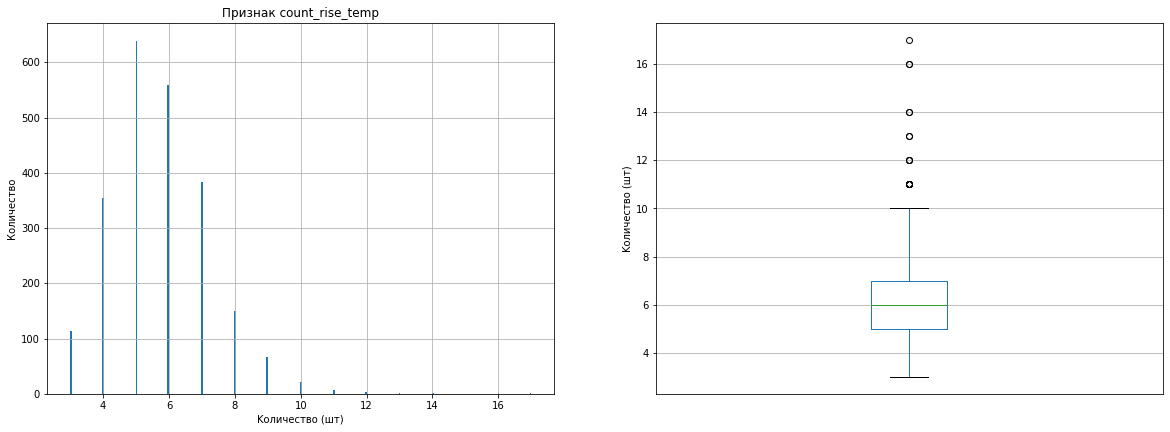

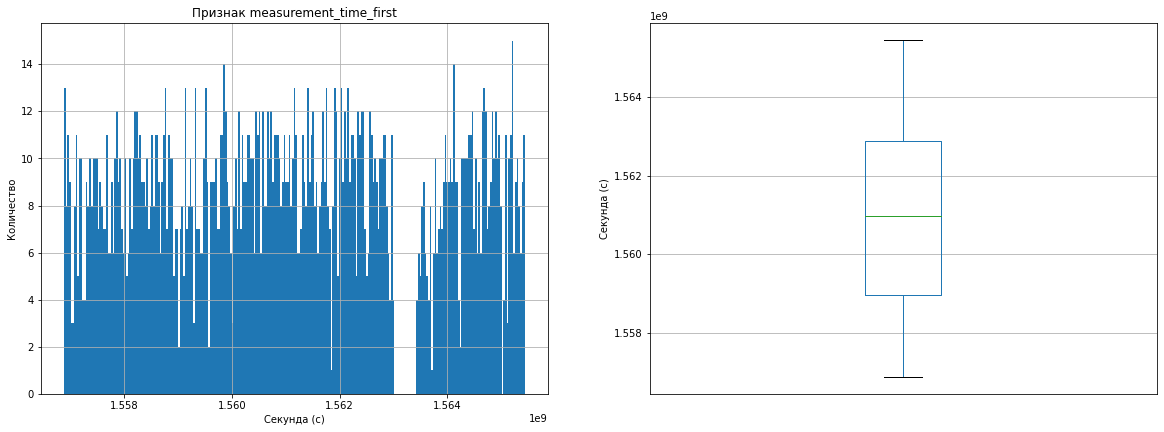

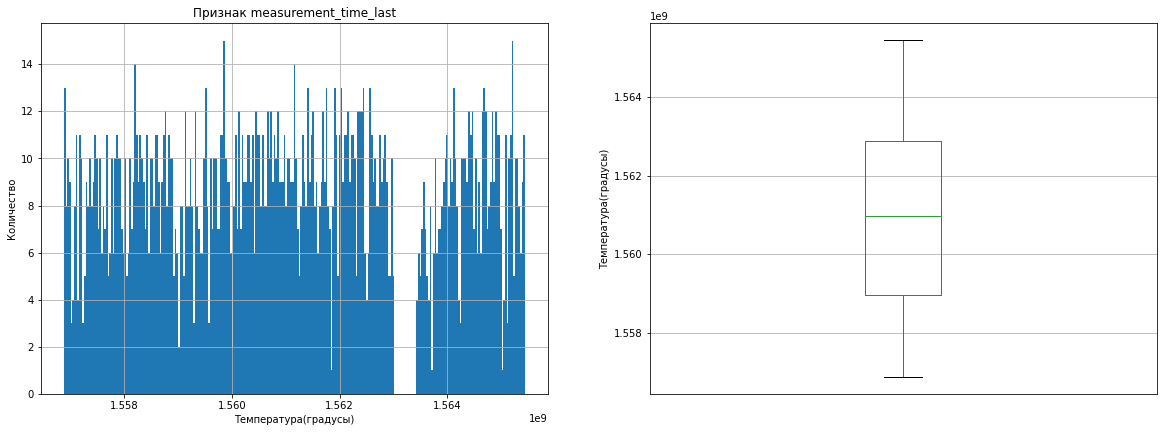

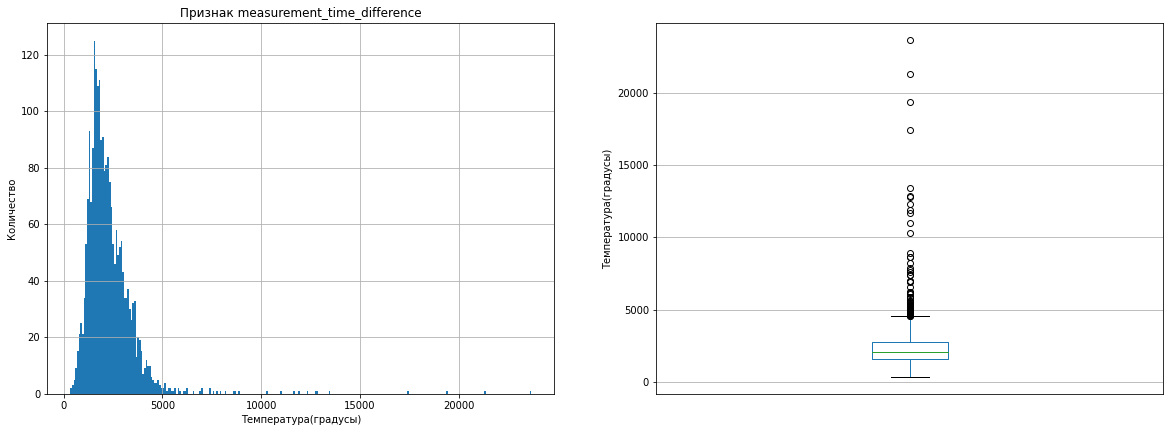

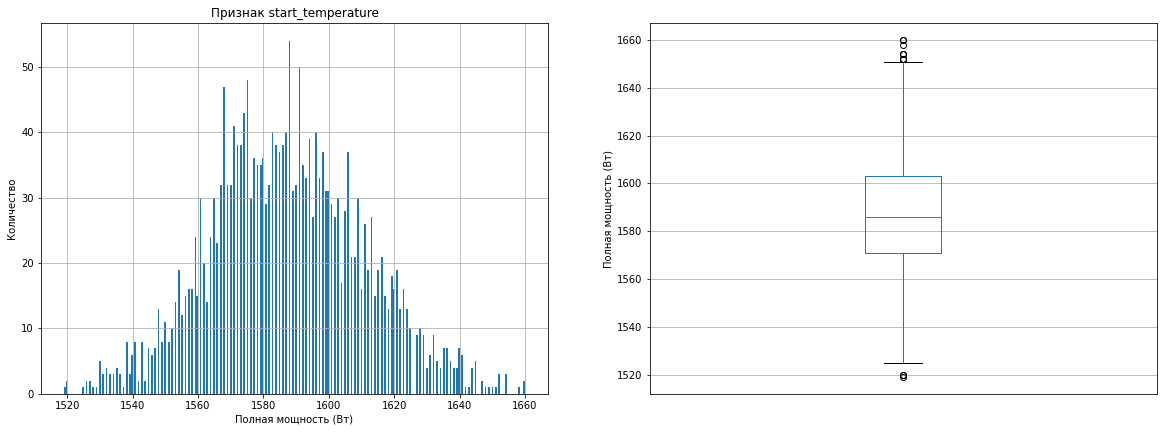

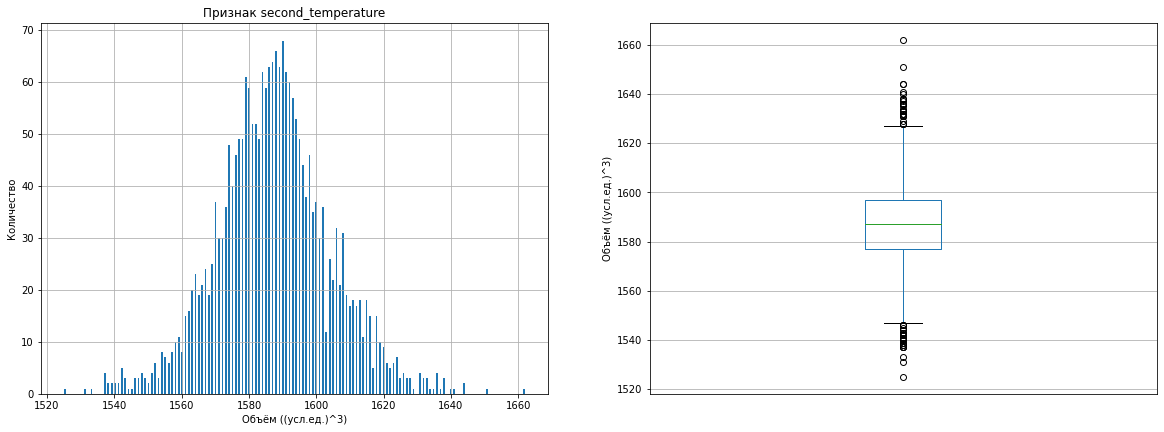

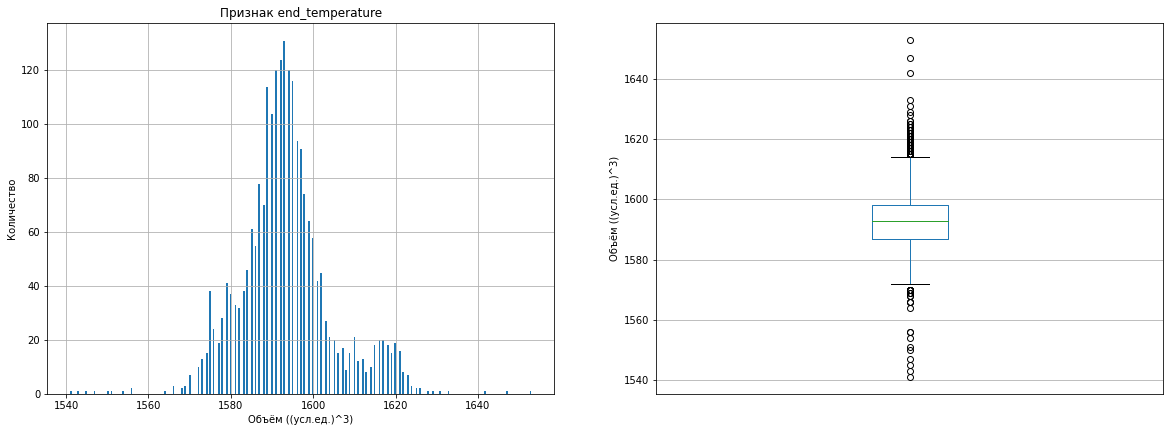

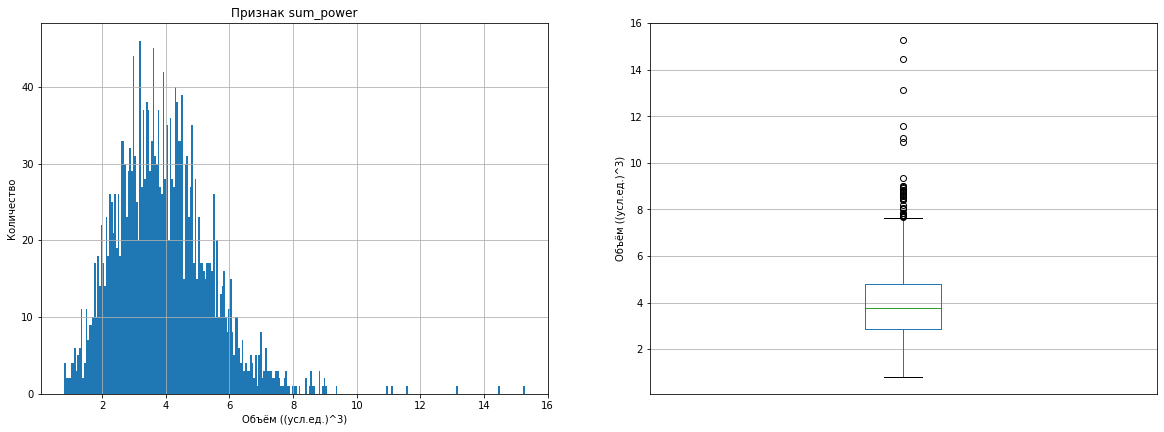

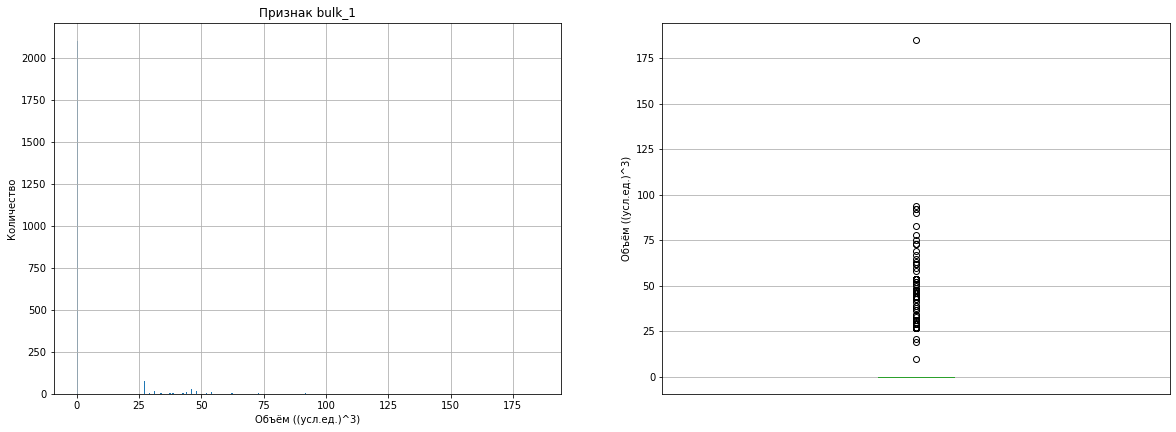

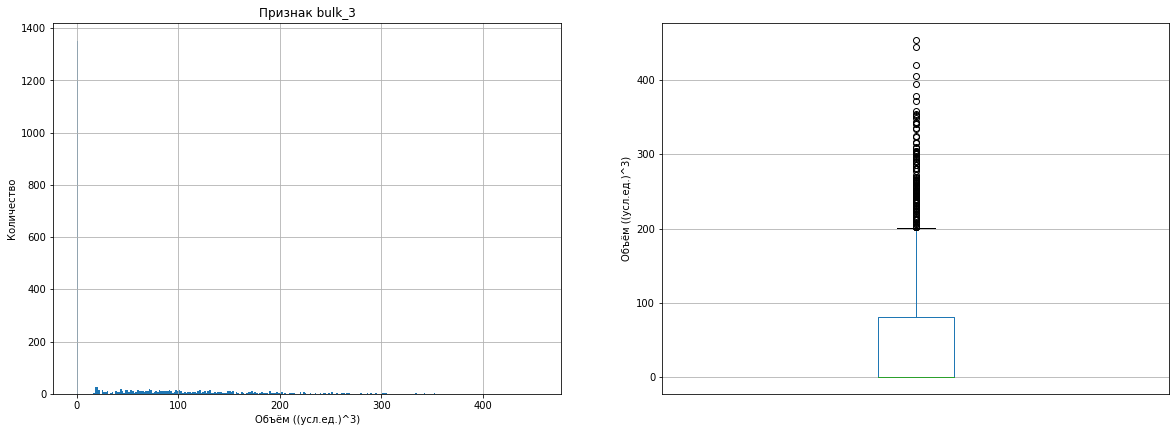

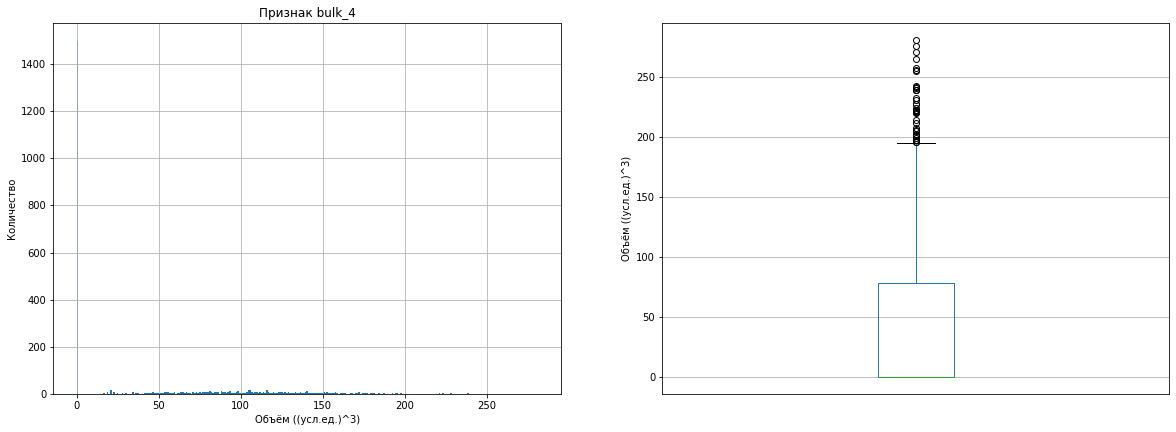

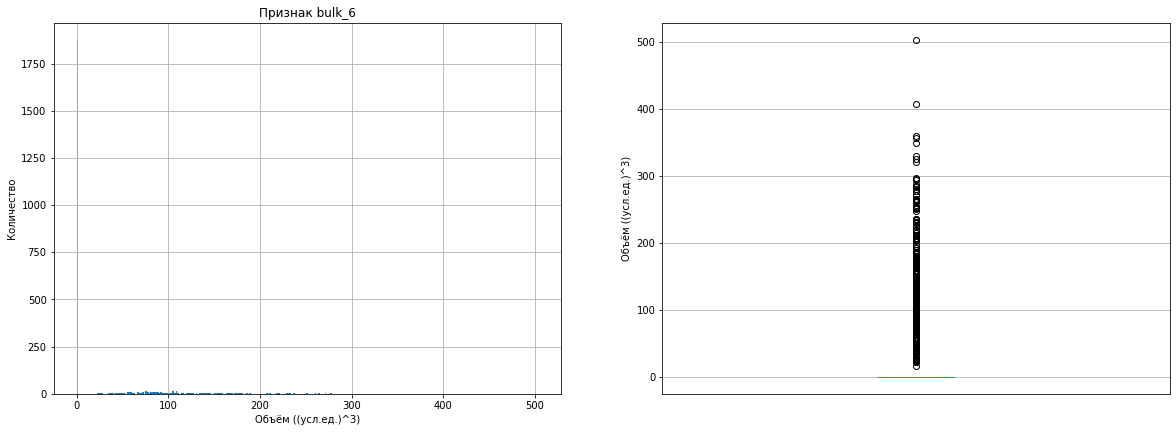

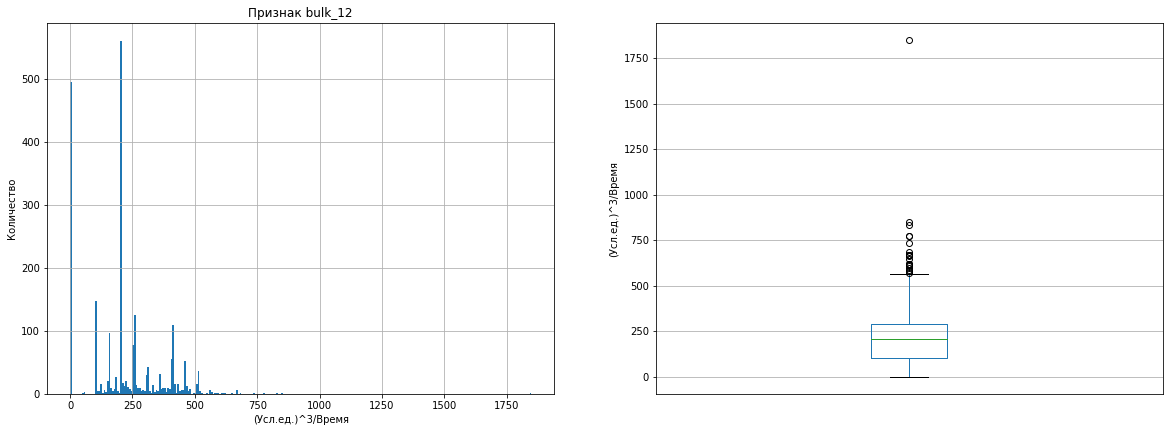

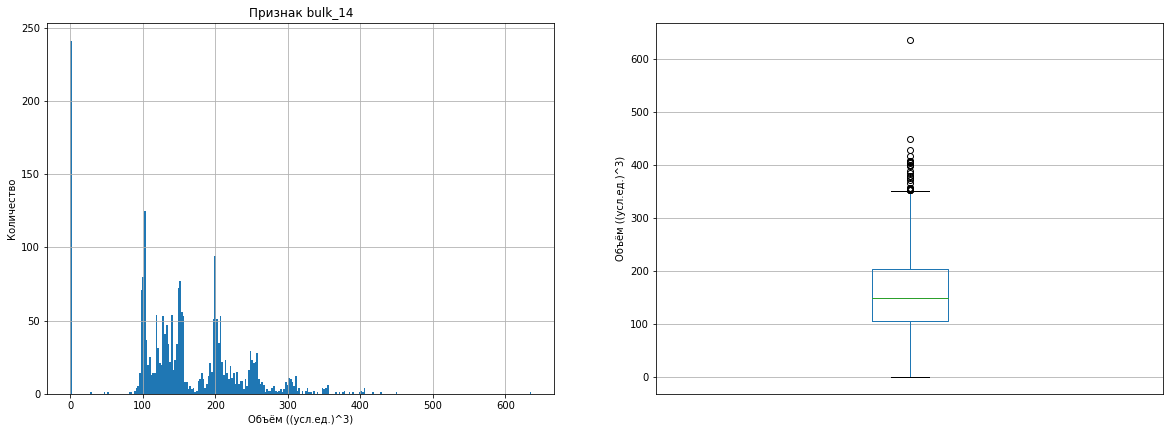

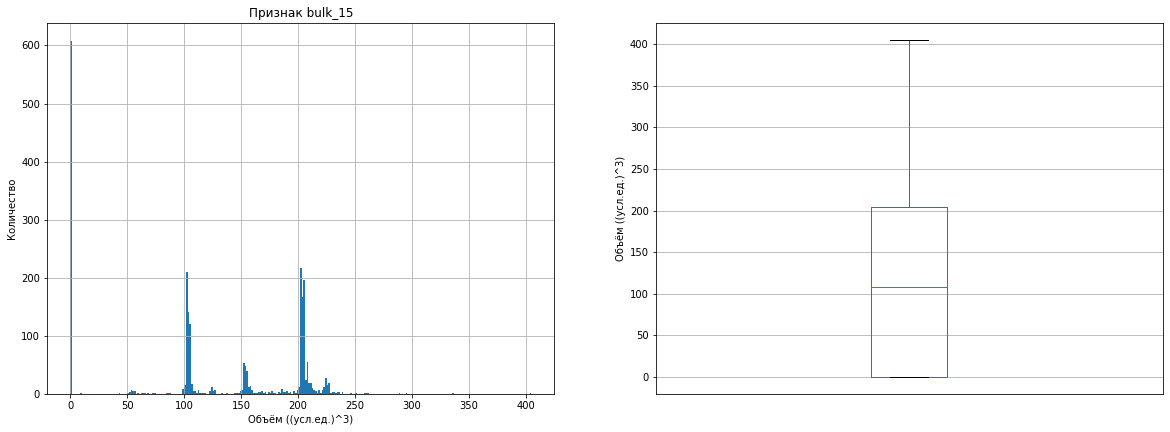

In [70]:
measure_x = ['Kоличество (шт)', 'Секунда (с)', 'Температура(градусы)', 'Температура(градусы)', 'Полная мощность (Вт)', 
             'Объём ((усл.ед.)^3)', 'Объём ((усл.ед.)^3)', 'Объём ((усл.ед.)^3)', 'Объём ((усл.ед.)^3)', 'Объём ((усл.ед.)^3)', 
             'Объём ((усл.ед.)^3)', 'Объём ((усл.ед.)^3)', '(Усл.ед.)^3/Время', 'Объём ((усл.ед.)^3)', 'Объём ((усл.ед.)^3)']
dataframe_count_analyse(all_data, 'all_data', measure_x)

Из результатов вывода видно, что у многих признаков больщое количество выбросов.

Удалять выбросы мы **не будем**, так как модель будет идеально работать на наших данных, но если пробовать другие, то результаты могут быть хуже; а также если будет проводиться удаление выбросов для кажого признака, то тогда от датафрема может ничего не остаться и модель будет также плохо работать.

### Корреляционный анализ



**Проведём корреляционный анализ признаков в датасетах**

Изучим взаимосвязь между признаками в датафрейме `all_data`. Для этого воспользуемся методом `.corr()`, который возвращает коэффициенты корреляции; перед этим удалим столбец `'key'`, так как он лишь показывает уникальный идентификатор партии, который никак не связан с остальными столбцами. 

In [71]:
all_data_corr = all_data.drop(columns=['key']).corr()

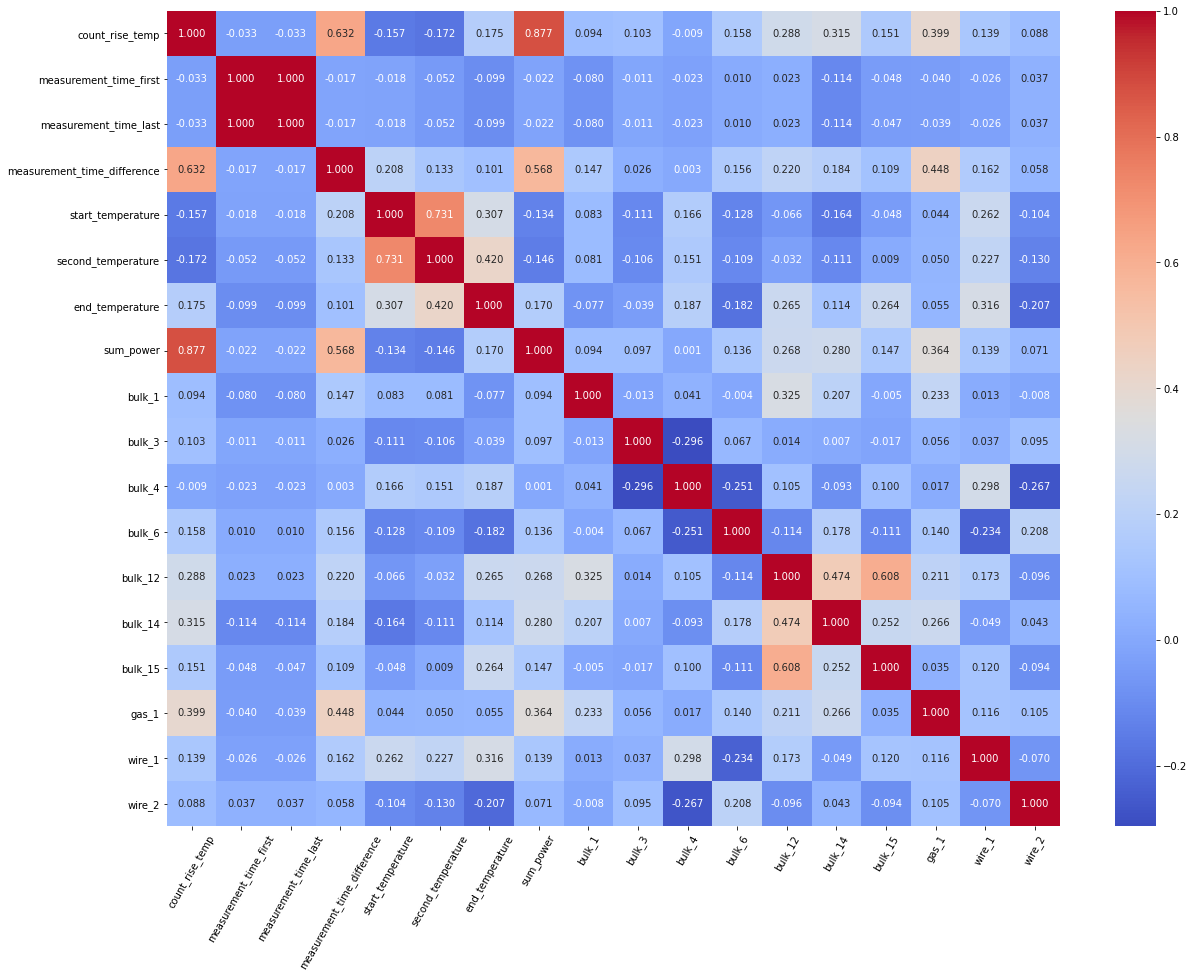

In [72]:
plt.figure(figsize=(20, 15))
sns.heatmap(all_data_corr, annot=True, fmt='.3f', cmap='coolwarm')
plt.xticks(rotation=60)
plt.show()

Из матрицы корреляций видно, что у некоторых признаков наблюдается **мультиколлинеарность**, а это может плохо сказаться на модели, так как будет приводить к ошибкам в предсказании результата. Поэтому удалим признаки: `'measurement_time_first'`, `'measurement_time_last'`, `'beginning_of_arc_heating'`,`'end_of_arc_heating'`, `'active_power'`, `'reactive_power'`:

In [73]:
all_data = all_data.drop(columns=['measurement_time_first', 'measurement_time_last'])

Снова выведем матрицу корреляций:

In [74]:
all_data_corr = all_data.drop(columns=['key']).corr()

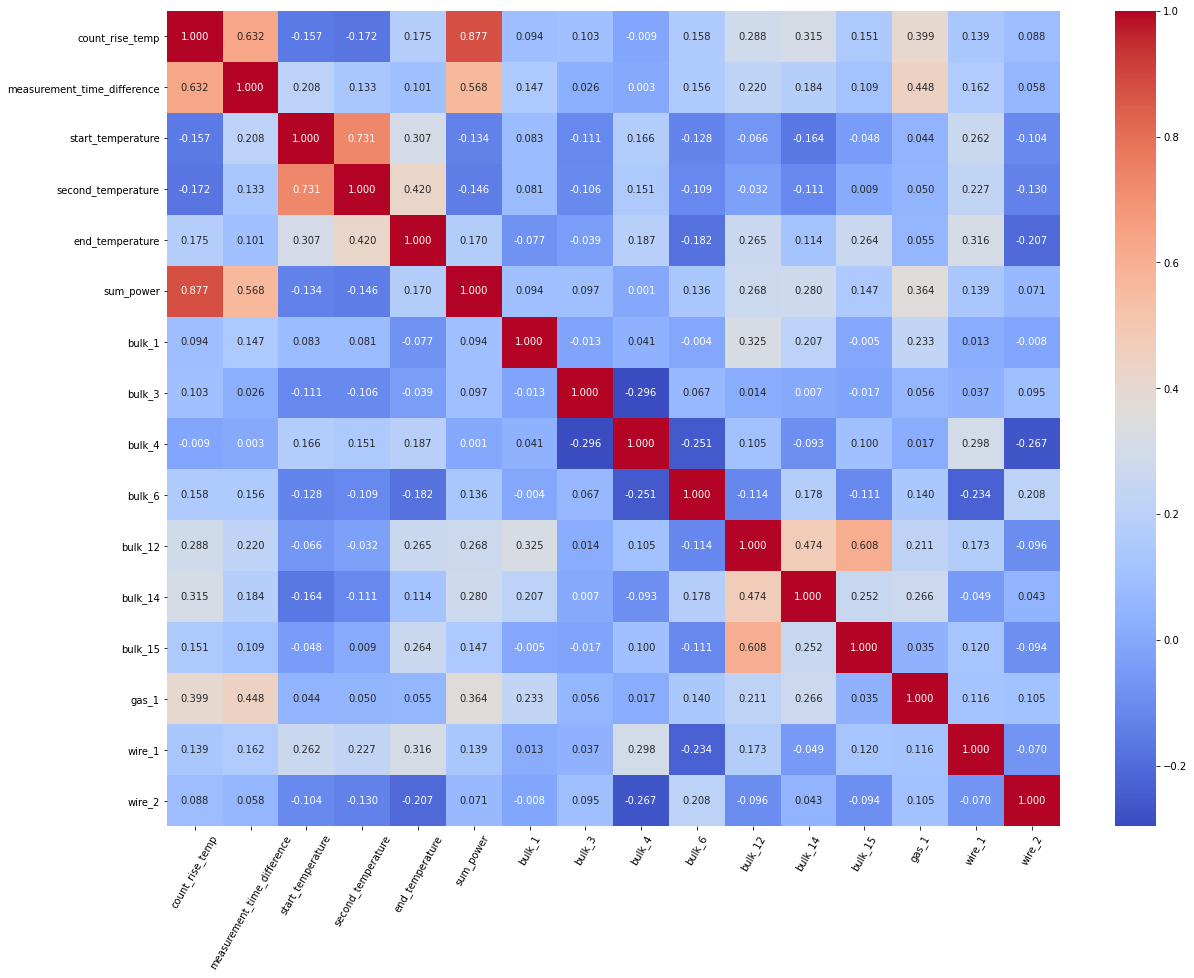

In [75]:
plt.figure(figsize=(20, 15))
sns.heatmap(all_data_corr, annot=True, fmt='.3f', cmap='coolwarm')
plt.xticks(rotation=60)
plt.show()

На тепловой карте удобно представлены результаты, по которым можно провести анализ. Согласно *шкале Чеддока* можно говорить о следующее: есть коррелирующие и некоррелирующие величины. Из тепловой карты наглядно видно: 
- **высокая** связь: `'sum_power'`-`'count_rise_temp'`
- **заметная** связь: `'measurement_time_difference'`-`'sum_power'`, `'start_temperature'`-`'second_temperature'`
- **заметная** связь: `'measurement_time_difference'`-`'count_rise_temp'`, `'bulk_12'`-`'bulk_15'`
- остальные признаки имеют  **умеренную** или **слабую** связь или её вообще нет 

Из повторного графика можно сказать, что говорить о **мультиколлениарности** тут уже нельзя.

**Промежуточный вывод:**

В результате предобработки и исследовательского анализа объединенного датафрейма было получено следующее:
- преобразовали столбцы типа `datetime` к формату Unix-время в связи с дальнейшими сложностями как корреляционного анализа, так и обучения моделей
- проверили на наличие пропусков
- проанализировали пропуски и заполнили их 0, так как это показывает, что материал не использовался для партии
- провели углубленный анализ гистограмм и диаграмм размаха
-  было проведено исследование на удаление или сохранение выбросов в результате которого было принято решение **не удалять** выбросы, так как не все графики имеют нормальное распределение, у некоторых либо крайне мало, либо крайне много выбросов, что может повлиять на результаты исследования, также идеально отлаженная модель может плохо работать на новых данных
- провели корреляционный анализ датафрейма
- построили тепловую карту матрицы корреляционных значений и проанализировали 
- сделали выводы о взаимосвязи признаков
- проанализировали и определили, что между признаками есть мультиколлениарность и приянли решение удалить признаки, которые этому способствуют

## Подготовка данных к обучению

Начнём подготовку данных к дальнейшему обучению.

Напишем функцию `preprocess_standard()`, которая будет проводить деление на выборки, а также масштабирование количественных признаков:

In [76]:
def preprocess_standard(X_dataframe, y_dataframe, RANDOM_STATE, TEST_SIZE, numerical_col):
    # разделение на тренировочную и тестовую выборки
    X_dataframe_train, X_dataframe_test, y_dataframe_train, y_dataframe_test = train_test_split(X_dataframe, y_dataframe,
        random_state=RANDOM_STATE, test_size=TEST_SIZE)
    
    # стандартизируем количественные данные с помощью StandardScaler()
    scaler = StandardScaler()
    
    # столбцы с количественными данными
    num_col = numerical_col
    
    X_dataframe_train[num_col] = scaler.fit_transform(X_dataframe_train[num_col])
    X_dataframe_test[num_col] = scaler.transform(X_dataframe_test[num_col])
    
    return X_dataframe_train, X_dataframe_test, y_dataframe_train, y_dataframe_test

In [77]:
# список количественных признаков
numerical_col = ['count_rise_temp', 'sum_power', 'bulk_1', 'bulk_3', 'bulk_4', 'bulk_6', 'bulk_12',
                 'bulk_14', 'bulk_15', 'gas_1', 'wire_1', 'wire_2']

Вызовем написанную ранее функцию `preprocess_standard()`:

In [78]:
X_train, X_test, y_train, y_test = preprocess_standard(all_data.drop(columns=['key', 'end_temperature']), all_data['end_temperature'], 220425, 0.25, numerical_col)

Отобразим данные в них, чтобы удостовериться в правильности вывода:

In [79]:
display(X_train, X_test, y_train, y_test)

,count_rise_temp,measurement_time_difference,start_temperature,second_temperature,sum_power,bulk_1,bulk_3,bulk_4,bulk_6,bulk_12,bulk_14,bulk_15,gas_1,wire_1,wire_2
2105,0.799358,2915.0,1628.0,1584.0,0.452765,-0.273011,-0.634223,0.888384,-0.410886,0.292070,-0.689245,-0.204377,0.671881,0.373409,-0.254515
2053,-0.487214,1781.0,1553.0,1584.0,-1.089762,-0.273011,-0.634223,-0.625843,0.080931,0.103239,-0.318138,1.261915,0.272598,-1.748260,-0.530645
234,0.799358,2972.0,1613.0,1588.0,-0.185305,4.763447,0.053034,-0.625843,-0.410886,0.638260,1.351845,0.999652,0.255004,0.189484,0.527020
952,-0.487214,1495.0,1587.0,1587.0,0.029369,-0.273011,-0.634223,-0.625843,-0.410886,-1.319286,0.337485,-1.444169,0.049262,0.420144,0.226897
473,0.156072,1589.0,1562.0,1567.0,0.185308,-0.273011,-0.383110,-0.625843,-0.410886,-0.664673,1.228142,-1.444169,-0.597880,-0.636240,2.394158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016,0.156072,2058.0,1588.0,1592.0,0.135951,-0.273011,0.013385,-0.625843,-0.410886,-0.016354,-0.318138,-0.216298,-0.244501,0.400761,0.074299
312,-0.487214,2642.0,1592.0,1574.0,-0.634251,-0.273011,1.639012,-0.625843,-0.410886,0.952978,0.708592,-0.216298,3.355198,-0.540401,-0.530645
1049,-0.487214,2378.0,1597.0,1607.0,-0.420907,-0.273011,1.506847,1.542254,-0.410886,0.040296,-0.627394,-0.252061,-0.279720,0.580593,-0.530645
269,-0.487214,1295.0,1576.0,1590.0,-0.854628,-0.273011,3.343938,-0.625843,-0.410886,-1.319286,-1.913899,-1.444169,-0.037323,-1.055778,-0.530645


,count_rise_temp,measurement_time_difference,start_temperature,second_temperature,sum_power,bulk_1,bulk_3,bulk_4,bulk_6,bulk_12,bulk_14,bulk_15,gas_1,wire_1,wire_2
1928,-0.487214,2244.0,1560.0,1582.0,-0.852767,-0.273011,-0.634223,-0.625843,1.100994,1.003333,1.995097,-1.444169,-0.071924,-2.045756,-0.530645
697,-1.130500,1993.0,1609.0,1607.0,-0.608203,-0.273011,1.110353,-0.625843,-0.410886,-1.319286,0.102450,-1.444169,-0.613450,0.043249,-0.530645
938,0.799358,2856.0,1564.0,1587.0,0.786373,-0.273011,-0.634223,-0.625843,1.246718,1.273990,0.597260,1.011573,1.887139,0.431989,-0.530645
1645,-0.487214,1512.0,1594.0,1592.0,-0.681017,-0.273011,-0.634223,-0.625843,-0.410886,-0.022648,-0.689245,-0.216298,-0.741263,-0.064436,-0.530645
1968,-1.773786,859.0,1619.0,1603.0,-1.857882,-0.273011,0.132333,-0.625843,-0.410886,-0.224068,-0.367619,0.415519,-0.217100,-0.067810,-0.530645
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1885,-0.487214,1494.0,1568.0,1579.0,-1.056371,-0.273011,-0.634223,-0.625843,1.119210,-0.299600,-0.590283,1.011573,-0.727489,-1.861831,-0.530645
275,-0.487214,1315.0,1571.0,1576.0,-0.208661,-0.273011,-0.634223,-0.625843,-0.410886,-0.041531,-0.008882,0.379756,1.588502,-0.776373,-0.530645
1350,0.156072,1841.0,1576.0,1578.0,0.476241,-0.273011,-0.634223,0.819555,-0.410886,-0.022648,-1.913899,-1.444169,0.038522,0.807808,-0.530645
1721,-0.487214,2589.0,1627.0,1602.0,-0.566456,-0.273011,0.370230,-0.625843,-0.410886,-1.319286,-0.441840,-1.444169,0.405115,-0.063359,0.415828


2105    1592.0
2053    1594.0
234     1591.0
952     1591.0
473     1582.0
         ...  
1016    1593.0
312     1597.0
1049    1598.0
269     1590.0
1904    1580.0
Name: end_temperature, Length: 1727, dtype: float64

1928    1596.0
697     1597.0
938     1582.0
1645    1595.0
1968    1594.0
         ...  
1885    1592.0
275     1587.0
1350    1601.0
1721    1586.0
1785    1581.0
Name: end_temperature, Length: 576, dtype: float64

Проверим размеры признаков:

In [80]:
display(X_train.shape)
display(y_train.shape)
display(X_test.shape)
display(y_test.shape)

(1727, 15)

(1727,)

(576, 15)

(576,)

Данные отображаются корректно и готовы для обучения моделей.

## Обучение моделей

Перед работой с разными моделями создадим списки, куда будем записывать их результаты, чтобы после было проще проанализировать и сравнить данные: 

In [81]:
# Создаем пустые списки для таблицы результатов 
models = []
parameters = []
mae_result_train = []

Для дальнейшей оптимизации кода и избежания его повторения напишем функцию, для обучения, поиска гиперпараметров, а также вычисления метрики МАE:

In [82]:
def train_ml_model(chosen_model, param_grid, n_iter=None, random_state = RANDOM_STATE):
    # создание переданной модели
    model = chosen_model

    # подбор гиперпараметров с использованием RandomizedSearchCV
    
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        n_iter=n_iter,
        cv=5,
        scoring='neg_mean_absolute_error', 
        n_jobs=-1,
        random_state=random_state
    )
    # oбучение модели
    random_search.fit(X_train, y_train)

    # лучшая модель, гиперпараметры и метрика
    best_model = random_search.best_estimator_
    best_params = random_search.best_params_
    best_mae = (-1) * random_search.best_score_

    return best_model, best_params, best_mae

Теперь для обучения моделей и поиска гиперпараметров будем вызывать данную функцию, передавая ей модель и словарь гиперпараметров.

### Модель LinearRegression()

Рассмотрим одну и наиболее часто применимых моделей за весь наш курс - LinearRegression():

Для этой модели рассмотрим метод `.cross_val_score()`:

In [84]:
lin_best_model = LinearRegression()
lin_best_params = '{not selected}'

In [85]:
lin_mae = sklearn.model_selection.cross_val_score(lin_best_model, X_train, y_train, scoring='neg_mean_absolute_error', cv=5)

In [86]:
lin_best_mae = (-1) * np.mean(lin_mae)

Запишем результаты в ранее сформированные списки для дальнейшего анализа:

In [88]:
models.append(lin_best_model)
parameters.append(lin_best_params)
mae_result_train.append(lin_best_mae)

In [89]:
print('Лучшие подобранные гиперпараметры исследованных моделей:', lin_best_params)
print('Лучшая метрика МАЕ исследованных моделей:', lin_best_mae)

Лучшие подобранные гиперпараметры исследованных моделей: {not selected}
Лучшая метрика МАЕ исследованных моделей: 6.646583724328961


В результате видно, что значение метрики МАЕ (`6.64658`) получилось вполне хорошее (физичное) и соответствует требованию заказчика быть меньше `6.8`.

### Модель DecisionTreeRegressor()

Рассмотрим следующую модель для обучения `DecisionTreeRegressor()`; также запишем словарь гиперпараметров для изучения и применим функцию `train_ml_model()`:

In [90]:
param_grid_tree = {
                    'max_depth': [5, 10, 15, 20, 25],  
                    'min_samples_split': [2, 5, 10],  
                    'max_features': ['auto', 'sqrt', 'log2']  
                  }

In [91]:
tree_best_model, tree_best_params, tree_best_mae = train_ml_model(DecisionTreeRegressor(random_state=RANDOM_STATE), param_grid_tree, n_iter=50)

/opt/conda/lib/python3.9/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 45 is smaller than n_iter=50. Running 45 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
75 fits failed out of a total of 225.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
75 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/conda/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/conda/lib/python3.9/site-packages/sklearn/base.py", line 1382, in wra

Запишем результаты в ранее сформированные списки для дальнейшего анализа:

In [92]:
models.append(tree_best_model)
parameters.append(tree_best_params)
mae_result_train.append(tree_best_mae)

In [93]:
print('Лучшие подобранные гиперпараметры исследованных моделей:', tree_best_params)
print('Лучшая метрика МАЕ исследованных моделей:', tree_best_mae)

Лучшие подобранные гиперпараметры исследованных моделей: {'min_samples_split': 10, 'max_features': 'sqrt', 'max_depth': 5}
Лучшая метрика МАЕ исследованных моделей: 7.4717764607172965


В результате видно, что значение метрики МАЕ получилось равное `7.47177`, что не соответствует требованию заказчика быть меньше `6.8`.

### Модель RandomForestRegressor()

Рассмотрим модель `RandomForestRegressor()`:

Запишем словарь рассматриваемых гиперпараметров:

In [94]:
param_grid_forest = {
                        'n_estimators': [100, 200, 300, 400, 500], 
                        'max_depth': [5, 10, 20, 30, 40],  
                        'min_samples_split': [2, 5, 10, 15, 20], 
                     }

Применим функцию `train_ml_model()`:

In [95]:
forest_best_model, forest_best_params, forest_best_mae = train_ml_model(RandomForestRegressor(random_state=RANDOM_STATE), param_grid_forest, n_iter=50)

Запишем результаты в ранее сформированные списки для дальнейшего анализа:

In [96]:
models.append(forest_best_model)
parameters.append(forest_best_params)
mae_result_train.append(forest_best_mae)

In [97]:
print('Лучшие подобранные гиперпараметры исследованных моделей:', forest_best_params)
print('Лучшая метрика МАЕ исследованных моделей:', forest_best_mae)

Лучшие подобранные гиперпараметры исследованных моделей: {'n_estimators': 500, 'min_samples_split': 2, 'max_depth': 10}
Лучшая метрика МАЕ исследованных моделей: 6.483421663959318


В результате видно, что значение метрики МАЕ получилось очень хорошее равное `6.48342`, и соответствует требованию заказчика быть меньше `6.8`.

### Модель CatBoostRegressor()

Теперь рассмотрим модель `CatBoostRegressor()` и проделаем аналогичные действия:

In [98]:
# список гиперпараметров
param_grid_catboost = {
    'iterations': [100, 250, 500, 750, 1000], 
    'learning_rate': [0.1, 0.2],  
    'depth': [4, 6, 8, 10, 12, 16]  
}

In [99]:
catboost_best_model, catboost_best_params, catboost_best_mae = train_ml_model(CatBoostRegressor(random_state=RANDOM_STATE, verbose=False), param_grid_catboost, n_iter=5)

Запишем результаты в ранее сформированные списки для дальнейшего анализа:

In [100]:
models.append(catboost_best_model)
parameters.append(catboost_best_params)
mae_result_train.append(catboost_best_mae)

In [101]:
print('Лучшие подобранные гиперпараметры исследованных моделей:', catboost_best_params)
print('Лучшая метрика МАЕ исследованных моделей:', catboost_best_mae)

Лучшие подобранные гиперпараметры исследованных моделей: {'learning_rate': 0.1, 'iterations': 500, 'depth': 4}
Лучшая метрика МАЕ исследованных моделей: 6.448356737584622


В результате видно, что значение метрики МАЕ получилось очень хорошее равное `6.44835`, и соответствует требованию заказчика быть меньше `6.8`.

### Модель LGBMRegressor()

Рассмотрим модель LGBMRegressor(). В связи с некоторыми особенностями, нам бы пришлось изменять категориальные переменные в датафрейме, но так как таких данных у нас нет, то проделаем аналогичные действия:

In [102]:
# список гиперпараметров
param_grid_lgbm = {
                    'boosting_type': ['gbdt', 'dart', 'goss'],  
                    'max_depth': [5,7,9], 
                    'n_estimators': [100, 250, 500, 750]
                  }

In [103]:
lgbm_best_model, lgbm_best_params, lgbm_best_mae = train_ml_model(lgb.LGBMRegressor(random_state = RANDOM_STATE), param_grid_lgbm, n_iter=5)

Запишем результаты в ранее сформированные списки для дальнейшего анализа:

In [104]:
models.append(lgbm_best_model)
parameters.append(lgbm_best_params)
mae_result_train.append(lgbm_best_mae)

In [105]:
print('Лучшие подобранные гиперпараметры исследованных моделей:', lgbm_best_params)
print('Лучшая метрика МАЕ исследованных моделей:', lgbm_best_mae)

Лучшие подобранные гиперпараметры исследованных моделей: {'n_estimators': 500, 'max_depth': 7, 'boosting_type': 'gbdt'}
Лучшая метрика МАЕ исследованных моделей: 6.717475901024367


В результате видно, что значение метрики МАЕ получилось очень хорошее равное `6.71747`, и соответствует требованию заказчика быть меньше `6.8`.

Запишем в `datatable` результаты проведенных исследований:

In [106]:
# данные об исследованных моделях
datatable = {
    'model': models,
    'parameters': parameters,
    'mae_result': mae_result_train,
}

Преобразуем теперь данные в датафрейм:

In [107]:
result_table = pd.DataFrame(datatable)
result_table

,model,parameters,mae_result
0,LinearRegression(),{not selected},6.646584
1,"DecisionTreeRegressor(max_depth=5, max_feature...","{'min_samples_split': 10, 'max_features': 'sqr...",7.471776
2,"(DecisionTreeRegressor(max_depth=10, max_featu...","{'n_estimators': 500, 'min_samples_split': 2, ...",6.483422
3,<catboost.core.CatBoostRegressor object at 0x7...,"{'learning_rate': 0.1, 'iterations': 500, 'dep...",6.448357
4,"LGBMRegressor(max_depth=7, n_estimators=500, r...","{'n_estimators': 500, 'max_depth': 7, 'boostin...",6.717476


Датафрейм успешно сформирован.

## Тестирование

### Анализ лучшей модели

Исходя из полученных результатов по разным моделям, выберем лучшую из них для проверки на тестовых данных. В условиях было сказано, что необходимо, чтобы значение метрики MAE на *тестовой* выборке должно быть не больше `6.8`. На кросс-валидационной это условие было выполнено почти у всех моделей.

Отсортируем ранее сформированный датафрейм с данными по убыванию, чтобы рассмотреть самые лучшие значения метрик MAE:

In [108]:
result_table.sort_values(by='mae_result')

,model,parameters,mae_result
3,<catboost.core.CatBoostRegressor object at 0x7...,"{'learning_rate': 0.1, 'iterations': 500, 'dep...",6.448357
2,"(DecisionTreeRegressor(max_depth=10, max_featu...","{'n_estimators': 500, 'min_samples_split': 2, ...",6.483422
0,LinearRegression(),{not selected},6.646584
4,"LGBMRegressor(max_depth=7, n_estimators=500, r...","{'n_estimators': 500, 'max_depth': 7, 'boostin...",6.717476
1,"DecisionTreeRegressor(max_depth=5, max_feature...","{'min_samples_split': 10, 'max_features': 'sqr...",7.471776


Видно, что в тройке лучших модели:
- `CatBoostRegressor(learning_rate=0.1, iterations=500, depth=4, random_state=RANDOM_STATE, verbose=False)` - `6.448357`
- `DecisionTreeRegressor(n_estimators=500, min_samples_split=2, max_depth=10)` - `6.483422`
- `LinearRegression()` - `6.646584`

Как можно заметить, все эти результаты не сильно отличаются друг от друга.

Самая лучшаяя метрика получилась у модели `CatBoostRegressor()`. У всех трёх моделей значения метрик МАЕ близки друг к другу (отличие в несколько сотых). В связи с этим выберем лучшей моделью - модель `CatBoostRegressor(learning_rate=0.1, iterations=500, depth=4, random_state=RANDOM_STATE, verbose=False)`, и на ней проверим результаты тестовой выборки.

### Тестирование лучшей выбранной модели

Проведем тестирование лучшей модели - `CatBoostRegressor(learning_rate=0.1, iterations=500, depth=4, random_state=RANDOM_STATE, verbose=False)`:

Напишем функцию `test_ml_model()`, которая проведет весь рассчёт; в неё будем передавать модель с лучшими гиперпараметрами:

In [109]:
def test_ml_model(model):
    # Инициализируем модель
    chosen_model = model
    
    # Обучим модель на тренировочных данных
    chosen_model.fit(X_train, y_train)
    
    # Получим предсказания модели на валидационных данных 
    # и сохраним результат в y_pred_chosen_model
    y_pred_chosen_model = chosen_model.predict(X_test)
    
    # Вычисление MAE
    mae = mean_absolute_error(y_test, y_pred_chosen_model)
    print('Метрика MAE для модели', chosen_model, ' :', round(mae,5))
    return 

Вызовем `test_ml_model()` к выбранной нами модели:

In [110]:
test_ml_model(CatBoostRegressor(learning_rate=0.1, iterations=500, depth=4, random_state=RANDOM_STATE, verbose=False))

Метрика MAE для модели <catboost.core.CatBoostRegressor object at 0x7ffb5a1031c0>  : 6.34509


Из результата проверки на тестовой выборке видно, что метрика МАЕ равна `6.34509`, что соответствует требованию заказчика быть менее `6.8`.

**Оценим важность признаков для лучшей модели**

In [111]:
explainer_1 = shap.Explainer(catboost_best_model.predict, X_train)
shap_values_1 = explainer_1(X_train)

PermutationExplainer explainer: 1728it [01:55, 14.13it/s]                          


Построим график важности с помощью метода SHAP:

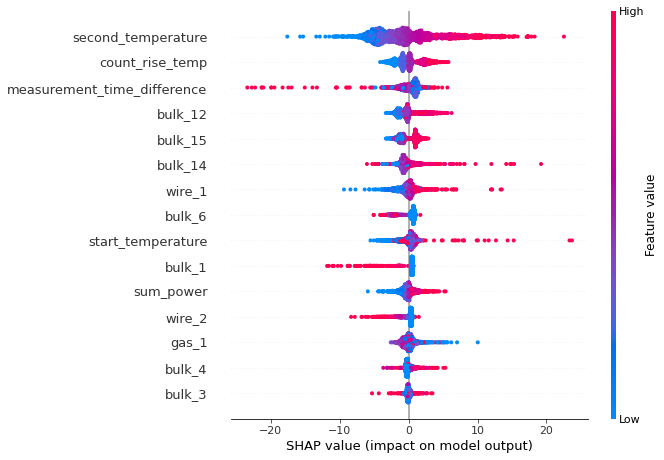

In [112]:
# построение графика с именами признаков
shap.plots.beeswarm(shap_values_1, max_display=16)

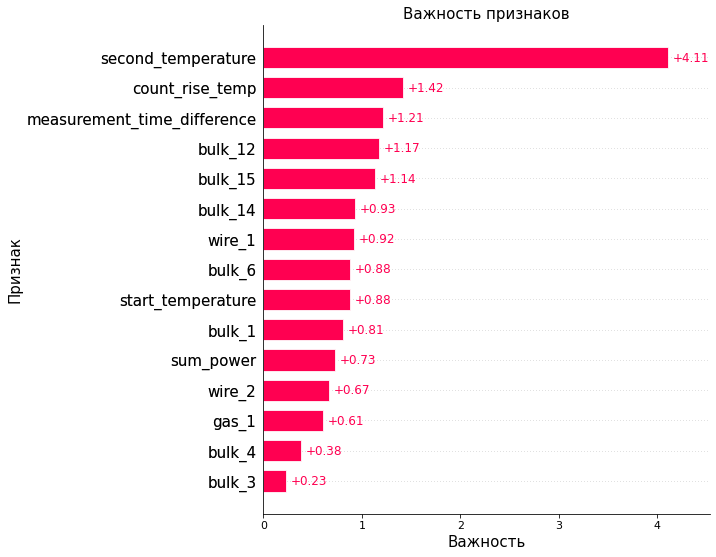

In [113]:
shap.plots.bar(shap_values_1, max_display=16, show=False)
plt.yticks(fontsize=15)
plt.xlabel('Важность', fontsize=15)
plt.ylabel('Признак', fontsize=15)
plt.title('Важность признаков', fontsize=15);

Из результатов графика можно сказать следующее:
- признаки, расположенные в верхней части графика, имеют наибольшее влияние на предсказания модели, а в нижней части - меньшее влияние
- положительные значения указывают на то, что признак увеличивает предсказание модели, а отрицательные значения - признак уменьшает предсказание модели
- красные точки (высокие значения признаков) и синие точки (низкие значения признаков) показывают, как различные значения признаков влияют на предсказания

Из представленных графиков следует, что *наибольшее* влияние имеют признаки: `second_temperature`, `count_rise_temp`, `measurement_time_difference`, `bulk_12` и `bulk_15`; а *наименьшее* - `bulk_3`, `bulk_4`, `gas_1`.

**Сделаем выводы о значимости признаков**

В результате оценки важности признаков были получены следующие результаты:
- наименее значимые признаки для модели были определены:
    - `bulk_3`
    - `bulk_4`
    - `gas_1`

- наиболее значимые признаки для модели были определены:
    - `second_temperature`
    - `count_rise_temp`
    - `measurement_time_difference`
    - `bulk_12`
    - `bulk_15`
    
Среди материалов самыми важными оказались `bulk_12` и `bulk_15`, что говорит нам о том, что чем чаще такие сыпучие материалы используют, тем сильнее они влияют на модель. Это стоит учитывать и в дальнейшем, так как `bulk_12` и `bulk_15` входит в тройку часто используемых. Также количество раз нагрева `count_rise_temp` как видно тоже играет важную роль и можно говорить, что чем чаще будет нагрев, тем лучше это будет для модели, так как она даст более точный результат. Время нагрева `measurement_time_difference` тоже показывает своё влияние на модель, что тоже стоит учитывать при дальнейшей работе. Признак `second_temperature` показал своё большее влияние, что говорит, что важнее всего вторая температура нагрева, чем даже самая первая.

## Общий вывод по исследованию

Сформулируем общий вывод из проведенного нами исследования:

- Загрузка данных:
    - считали CSV-файл 
- Предобработка данных и исследовательский анализ датафреймов:
    - изучили общую информацию о датафреймах и выявили неточности, которые нужно устранить
    - привели названия столбцов к "правильной" записи (строчные буквы, латинский алфавит, змеевидная запись)
    - преобразовали типы данных столбцов с датой и временем от `object` к `datetime`
    - проверили данные на наличие пропусков
    - приняли решение **не удалять** пропуски, так как их критически много, что может полностью исказить результаты исследования
    - проверили данные на дубликаты и выяснили, что их нет
    - провели углубленный анализ данных
    - проанализировали гистограммы и диаграммы размаха для каждого датафрейма
    - было проведено исследование на удаление или сохранение выбросов в результате которого было принято решение **не удалять** выбросы, так как не все графики имеют нормальное распределение, у некоторых либо крайне мало, либо крайне много выбросов, что может повлиять на результаты исследования, также идеально отлаженная модель может плохо работать на новых данных
    - добавили новые признаки в некоторые датафреймы

- Объединение признаков:
    - объединили необходимые датафреймы с новыми признаками в один

- Предобработка и исследовательский анализ объединенного датафрейма:
    - преобразовали столбцы типа `datetime` к формату Unix-время в связи с дальнейшими сложностями как корреляционного анализа, так и обучения моделей
    - проверили на наличие пропусков
    - проанализировали пропуски и заполнили их 0, так как это показывает, что материал не использовался для партии
    - провели углубленный анализ гистограмм и диаграмм размаха
    -  было проведено исследование на удаление или сохранение выбросов в результате которого было принято решение **не удалять** выбросы, так как не все графики имеют нормальное распределение, у некоторых либо крайне мало, либо крайне много выбросов, что может повлиять на результаты исследования, также идеально отлаженная модель может плохо работать на новых данных
    - провели корреляционный анализ датафрейма
    - построили тепловую карту матрицы корреляционных значений и проанализировали 
    - сделали выводы о взаимосвязи признаков
    - проанализировали и определили, что между признаками есть мультиколлениарность и приянли решение удалить признаки, которые этому способствуют

- Подготовка данных к обучению:
    - написали функцию для разделения датафрейма на тренировочную и тестовую выборки
    - проверили размеры и записанные в них данные

- Обучение моделей:

Для обучения моделей рассматривались модели:
- `LinearRegression()`
- `DecisionTreeRegressor()`
- `RandomForestRegressor()`
- `CatBoostRegressor()`
- `LGBMRegressor()`


Согласно поставленным нам критериям были получены следующие модели, которые справились лучше всего с каждым из критериев:
- метрика качества предсказания у моделей (MAE):
    - `CatBoostRegressor(learning_rate=0.1, iterations=500, depth=4, random_state=RANDOM_STATE, verbose=False)` - MAE = `6.448357`
    - `DecisionTreeRegressor(n_estimators=500, min_samples_split=2, max_depth=10)` - MAE = `6.483422`
    - `LinearRegression()` - MAE = `6.646584`

Как можно заметить, все эти результаты не сильно отличаются друг от друга.

Самая лучшая метрика получилась у модели `CatBoostRegressor()`. У всех трёх моделей значения метрик МАЕ близки друг к другу (отличие в несколько сотых). В связи с этим выберем лучшей моделью - модель `CatBoostRegressor(learning_rate=0.1, iterations=500, depth=4, random_state=RANDOM_STATE, verbose=False)`, и на ней проверим результаты тестовой выборки.  

Из проведенного анализа метрик MAE, переборе разных гипермараметров в моделях можно говорить о том, что лучше всего справилась модель `CatBoostRegressor()` и результатом метрики MAE на тестовой выборке `6.34509`, что вполне удовлетворяет требованию быть меньше `6.8`. Исходя из полученного результата, металлургическому комбинату «Стальная птица» рекомендуется использовать именно эту модель - `CatBoostRegressor(learning_rate=0.1, iterations=500, depth=4, random_state=RANDOM_STATE, verbose=False)`. 

- проведи анализ важности признаков:

    В результате оценки важности признаков были получены следующие результаты:
    - наименее значимые признаки для модели были определены:
        - `bulk_3`
        - `bulk_4`
        - `gas_1`

    - наиболее значимые признаки для модели были определены:
        - `second_temperature`
        - `count_rise_temp`
        - `measurement_time_difference`
        - `bulk_12`
        - `bulk_15`
    
Среди материалов самыми важными оказались `bulk_12` и `bulk_15`, что говорит нам о том, что чем чаще такие сыпучие материалы используют, тем сильнее они влияют на модель. Это стоит учитывать и в дальнейшем, так как `bulk_12` и `bulk_15` входит в тройку часто используемых. Также количество раз нагрева `count_rise_temp` как видно тоже играет важную роль и можно говорить, что чем чаще будет нагрев, тем лучше это будет для модели, так как она даст более точный результат. Время нагрева `measurement_time_difference` тоже показывает своё влияние на модель, что тоже стоит учитывать при дальнейшей работе. Признак `second_temperature` показал своё большее влияние, что говорит, что важнее всего вторая температура нагрева, чем даже самая первая.